# Hausse de loyer 2026 — Collection Équinoxe (JADCO)

**Objectif.** Estimer la hausse de loyer 2026 des immeubles de la Collection Équinoxe à partir de l'historique des baux : nommer et défendre la définition mesurée, comparer chaque unité à elle-même sur la bonne clé, traiter les concessions, séparer renouvellements et relocations selon les règles de chaque province, intégrer les données publiques et valider la prévision par backtest.

**Organisation.** Le notebook suit la démarche du mandat : *Définir → Mesurer → Tester → Défendre*.

| Section | Étape | Contenu |
|---|---|---|
| 1 | Définir | La hausse mesurée : définitions candidates et choix |
| 2 | Mesurer | Les données : colonnes vérifiées et renommées, clé d'unité, effet de composition |
| 3 | Mesurer | Hausse à unité constante sur `sPropCode` + `sUnitCode` |
| 4 | Mesurer | Concessions : loyer contractuel et loyer effectif |
| 5 | Mesurer | Renouvellements et relocations, Québec et Ontario |
| 6 | Tester | Données publiques (TAL, Ontario, IPC, SCHL) et signaux internes |
| 7 | Tester | Prévision 2026 et backtest 2021-2025 |
| 8 | Défendre | Bilan |
| 9 | Défendre | Références |

**Confidentialité.** Les données CRM ne sont jamais affichées ligne par ligne. Par immeuble ou par nombre de chambres, seuls des hausses en % et des nombres de baux sont publiés; les montants en $ restent au niveau du portefeuille ou de la province; toute case calculée sur moins de 5 baux ou paires est masquée.

Le notebook s'exécute de haut en bas depuis son dossier. Il écrit deux fichiers : `rent_model.json` (paramètres de la méthode retenue) et `output/results.json` (résultats agrégés).

### Paramètres

Tous les seuils, années et ratios sont regroupés dans la cellule suivante. Leur justification :

| Constante | Valeur | Justification |
|---|---|---|
| `DATA_AS_OF` | 2025-12-31 | Date de l'extrait CRM; rien après cette date n'est utilisé. |
| `FORECAST_YEAR` | 2026 | Année à prévoir. |
| `DISPLAY_FIRST_YEAR` | 2018 | Les baux commencent en janvier 2017 : 2018 est la première année où une unité peut avoir un bail précédent. |
| `BACKTEST_FIRST_YEAR` | 2021 | La tendance interne sur trois ans demande des paires 2018-2020. |
| `IMPOSED_TEST_FIRST_YEAR` | 2023 | Le test imposé porte sur 2023, 2024 et 2025. |
| `TREND_WINDOW_YEARS` | 3 | Fenêtre de la méthode concurrente « tendance interne ». |
| `MIN_GAP_YEARS`, `MAX_GAP_YEARS` | 0,5 et 2,5 ans | Bornes de l'écart entre deux baux comparés (justifiées à la section 3.2). |
| `DAYS_PER_YEAR` | 365,25 | Année moyenne, pour annualiser. |
| `DAYS_PER_MONTH` | 30,44 | Diviseur utilisé par le CRM pour `sTermMonths` (vérifié à la section 2.5). |
| `MIN_CELL_SIZE` | 5 | Confidentialité : toute case de moins de 5 baux, paires ou unités est masquée. |
| `INTERNAL_WEIGHT` | 0,5 | Poids égaux entre tendance interne et ancre externe (section 7.2). |
| `NEW_BUILDING_MAX_AGE_YEARS` | 5 | Section F du bail au Québec : immeuble de 5 ans ou moins, le TAL ne fixe pas le loyer. |
| `ONTARIO_EXEMPTION_DATE` | 2018-11-15 | En Ontario, un logement occupé pour la première fois après cette date est exempté de la ligne directrice (cas de The Met). |
| `LARGE_UNIT_MIN_BEDROOMS` | 2 | Indicateur de composition : part des baux de 2 chambres et plus. |
| `SHORT_CREDIT_MAX_MONTHS` | 2 | Un crédit sur 2 mois ou moins est ponctuel, pas mensuel (constat PromoPay). |
| `ASKING_LOOKBACK_MONTHS` | 3 | Un loyer affiché compte comme signal d'une relocation signée dans les 3 mois suivants. |
| `RENT_MATCH_TOLERANCE` | 0,02 $ | Écart d'arrondi accepté quand on recalcule un loyer au cent près. |
| `CPI_SERIES` | 4 vecteurs | Statistique Canada 18-10-0004-01 : loyers et ensemble, Québec et Ontario. |
| `CMHC_AREAS` | 7 secteurs | RMR de Montréal et d'Ottawa et les zones SCHL des villes des immeubles. |
| Couleurs, tailles et traits des graphiques | — | Charte de JADCO : marine, or, bronze, gris. |

In [1]:
import json
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
DATA_DIR = Path()
PUBLIC_DIR = DATA_DIR / "public_sources"
OUTPUT_DIR = DATA_DIR / "output"
CRM_FILES = {
    "listings": DATA_DIR / "equinoxe_listings.csv",
    "leases": DATA_DIR / "equinoxe_lease_history.csv",
    "concessions": DATA_DIR / "equinoxe_concessions.csv",
    "asking": DATA_DIR / "equinoxe_asking_history.csv",
}
TAL_FILE = PUBLIC_DIR / "tal_reference_rates.csv"
ONTARIO_FILE = PUBLIC_DIR / "ontario_rent_guideline.csv"
CPI_ZIP_FILE = PUBLIC_DIR / "18100004-eng.zip"
CPI_CSV_NAME = "18100004.csv"
CMHC_FILES = {
    "montreal": PUBLIC_DIR / "cmhc_montreal_2025.xlsx",
    "ottawa": PUBLIC_DIR / "cmhc_ottawa_2025.xlsx",
}
MODEL_FILE = DATA_DIR / "rent_model.json"
RESULTS_FILE = OUTPUT_DIR / "results.json"

DATA_AS_OF = pd.Timestamp("2025-12-31")
LAST_DATA_YEAR = DATA_AS_OF.year
FORECAST_YEAR = 2026
DISPLAY_FIRST_YEAR = 2018
BACKTEST_FIRST_YEAR = 2021
IMPOSED_TEST_FIRST_YEAR = 2023
DISPLAY_YEARS = list(range(DISPLAY_FIRST_YEAR, FORECAST_YEAR))
BACKTEST_YEARS = list(range(BACKTEST_FIRST_YEAR, FORECAST_YEAR))
IMPOSED_TEST_YEARS = list(range(IMPOSED_TEST_FIRST_YEAR, FORECAST_YEAR))
TREND_WINDOW_YEARS = 3
INFORMATION_CUTOFF = "fin janvier de l'année cible"

MIN_GAP_YEARS = 0.5
MAX_GAP_YEARS = 2.5
DAYS_PER_YEAR = 365.25
DAYS_PER_MONTH = 30.44
TERM_MONTHS_DECIMALS = 1
MONTHS_PER_YEAR = 12
PERCENT = 100
DECIMALS = 2
NARROW_SPACE = " "
WEIGHT_DECIMALS = 4

MIN_CELL_SIZE = 5
MASK_LABEL = f"masqué (moins de {MIN_CELL_SIZE})"
INTERNAL_WEIGHT = 0.5
NEW_BUILDING_MAX_AGE_YEARS = 5
ONTARIO_EXEMPTION_DATE = pd.Timestamp("2018-11-15")
LARGE_UNIT_MIN_BEDROOMS = 2
SHORT_CREDIT_MAX_MONTHS = 2
ASKING_LOOKBACK_MONTHS = 3
RENT_MATCH_TOLERANCE = 0.02

UNIT_KEY = ["prop_code", "unit_code"]
SITE_KEY = ["site", "unit_code"]
SEGMENT_COLUMNS = ["province", "segment"]
PREVIOUS_LEASE_COLUMNS = [
    "lease_start",
    "contract_rent",
    "effective_rent",
    "discount_pct",
    "term_months",
    "has_concession",
]
DATE_COLUMNS = [
    "sign_date",
    "lease_start",
    "lease_end",
    "move_in_date",
    "available_date",
    "listed_as_of",
    "credit_start",
    "credit_end",
    "asking_month",
]
QUEBEC = "QC"
ONTARIO = "ON"
PROVINCE_CODES = {"Quebec": QUEBEC, "Ontario": ONTARIO}
RENEWAL = "renouvellement"
RELOCATION = "relocation"
SEGMENT_LABELS = {True: RENEWAL, False: RELOCATION}
BUILDING_NAMES = {
    "stelz1": "Saint-Elzéar 1",
    "stelz2": "Saint-Elzéar 2",
    "stelz3": "Saint-Elzéar 3",
    "levesque": "Lévesque",
    "dj1": "Daniel-Johnson 1",
    "dj2": "Daniel-Johnson 2",
    "carlyle": "Le Carlyle",
    "wsp1": "Westpark",
    "metcalfe": "The Met",
}
BEDROOM_LABELS = {0: "Studio", 1: "1 chambre", 2: "2 chambres", 3: "3 chambres"}
PROMOPAY_CODE = "PromoPay"
THE_MET_CODE = "metcalfe"
TRUNCATED_BUILDING_CODE = "stelz1"
LEASE_UP_BUILDING_CODE = "stelz3"
REGIME_TAL = f"TAL : taux de référence (immeuble de plus de {NEW_BUILDING_MAX_AGE_YEARS} ans)"
REGIME_SECTION_F = (
    f"Section F : immeuble de {NEW_BUILDING_MAX_AGE_YEARS} ans ou moins, loyer non fixé par le TAL"
)
REGIME_ONTARIO_EXEMPT = (
    f"Ontario : exemptée de la ligne directrice (premier bail après le {ONTARIO_EXEMPTION_DATE.date()})"
)
REGIME_ONTARIO_GUIDELINE = "Ontario : ligne directrice"
LEASE_UP_NOTE = "Location initiale : aucune paire, prévision de sa province"

CHOSEN_METHOD = "combination"
SIMPLE_METHODS = ["persistence", "internal_trend", "external_anchor"]
HEADLINE_NOTE = (
    "Médiane sur toutes les paires comparables (chaque bail pèse autant), et non moyenne pondérée des "
    "médianes de segment."
)
HEADLINE_DEFINITION = (
    "Hausse annualisée du loyer effectif (sRentEffective) à unité constante : chaque unité "
    "(sPropCode + sUnitCode) comparée à son bail précédent; médiane sur toutes les paires comparables "
    "(premiers baux et paires hors filtre d'écart exclus), renouvellements et relocations selon leur part "
    "observée."
)

CPI_SERIES = pd.DataFrame(
    {
        "vector": ["v41691818", "v41691954", "v41691783", "v41691919"],
        "province": [QUEBEC, ONTARIO, QUEBEC, ONTARIO],
        "series": ["rent", "rent", "all_items", "all_items"],
    }
)
CPI_COLUMNS = ["REF_DATE", "VECTOR", "VALUE"]
CPI_CHUNK_ROWS = 200_000
RENT_SERIES = "rent"

CMHC_SHEETS = {"rent_change": "Table 1.1.5", "vacancy": "Table 1.1.1", "turnover": "Table 1.1.6"}
CMHC_TOTAL_LABEL = "Total"
CMHC_PREVIOUS_OFFSET = 0
CMHC_LATEST_OFFSET = 2
CMHC_QUALITY_OFFSET = 1
CMHC_LATEST_YEAR = LAST_DATA_YEAR
CMHC_PREVIOUS_YEAR = CMHC_LATEST_YEAR - 1
CMHC_AREAS = pd.DataFrame(
    {
        "market": ["montreal", "montreal", "montreal", "montreal", "montreal", "ottawa", "ottawa"],
        "label": [
            "Montréal CMA",
            "Laval (Zones 19-24)",
            "Zone 19 - Chomedey/Sainte-Dorothée",
            "Zone 5 - Ct-des-Neiges/Mt-Royal/Outremont",
            "Zone 15 - Baie-d'Urfé/Beaconsfield etc.",
            "Ottawa CMA",
            "Zone 1 - Downtown",
        ],
        "area": [
            "RMR de Montréal",
            "Laval (zones 19 à 24)",
            "Laval, zone 19 (Chomedey/Sainte-Dorothée)",
            "Montréal, zone 5 (Côte-des-Neiges/Mont-Royal/Outremont)",
            "Montréal, zone 15 (Ouest-de-l'Île)",
            "RMR d'Ottawa",
            "Ottawa, zone 1 (centre-ville)",
        ],
    }
)

NAVY = "#0B1F41"
GOLD = "#C9B88E"
BRONZE = "#8B7543"
GREY = "#5A606B"
LIGHT = "#F1F3F7"
FIGURE_SIZE = (10, 4.5)
WIDE_FIGURE_SIZE = (14, 4.2)
TALL_FIGURE_SIZE = (11, 5.5)
PANEL_WIDTH_RATIOS = [2, 1]
HEATMAP_TEXT_SWITCH = 0.5
AXIS_LINE_WIDTH = 0.8
THIN_LINE_WIDTH = 1.2
BOLD_LINE_WIDTH = 2.5
SECONDARY_ALPHA = 0.6
BAR_WIDTH = 0.4
BAR_OFFSET = BAR_WIDTH / 2
LEGEND_BELOW = {"loc": "upper center", "bbox_to_anchor": (0.5, -0.1), "ncol": 3}
CHART_STYLE = {
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titleweight": "bold",
    "axes.titlesize": 11,
    "axes.titlecolor": NAVY,
    "axes.labelcolor": GREY,
    "legend.frameon": False,
}

STATCAN_URL = "https://www150.statcan.gc.ca/t1/tbl1/fr/tv.action?pid=1810000401"
CMHC_URL = (
    "https://www.cmhc-schl.gc.ca/professionals/housing-markets-data-and-research/housing-data/"
    "data-tables/rental-market/rental-market-report-data-tables"
)
CLEMEN_URL = "https://doi.org/10.1016/0169-2070(89)90012-5"

### Outils communs

Formatage des nombres en français, affichage des tableaux (une case masquée apparaît comme « masqué (< 5) »), style des graphiques aux couleurs de JADCO, et conversion des résultats en JSON (une valeur manquante devient `null`).

In [3]:
plt.rcParams.update(CHART_STYLE)
heatmap_colors = LinearSegmentedColormap.from_list("jadco", [LIGHT, NAVY])

column_labels = {
    "name": "nom",
    "rows": "lignes",
    "columns": "colonnes",
    "description": "description",
    "table": "table",
    "column": "colonne",
    "distinct_values": "valeurs distinctes",
    "value": "valeur",
    "source": "nom Yardi",
    "renamed": "nom descriptif",
    "meaning": "sens",
    "columns_before": "colonnes au départ",
    "columns_dropped": "colonnes constantes retirées",
    "columns_after": "colonnes après",
    "columns_added": "colonnes calculées ajoutées",
    "documented_as": "ce que le nom laisse croire",
    "actually": "ce que montrent les données",
    "evidence": "preuve calculée",
    "site": "site (sSite)",
    "units": "unités",
    "prop_codes": "codes de propriété",
    "colliding_units": "unités en collision sur sSite + sUnitCode",
    "year": "année",
    "leases": "baux",
    "buildings": "immeubles",
    "median_contract_rent": "loyer contractuel médian ($, portefeuille)",
    "naive_change_pct": "variation de la médiane (%)",
    "median_sqft": "superficie médiane (pi²)",
    "share_large_pct": f"part {LARGE_UNIT_MIN_BEDROOMS} chambres et plus (%)",
    "median_rent_per_sqft": "loyer médian au pi² ($, portefeuille)",
    "rent_per_sqft_change_pct": "variation du loyer au pi² (%)",
    "building": "immeuble",
    "first_lease_year": "premier bail",
    "units_without_successor": "unités dont le dernier bail est terminé sans bail suivant",
    "share_without_successor_pct": "part de ces unités (%)",
    "gap_class": "écart entre les débuts de bail",
    "pairs": "paires",
    "median_gap_days": "écart médian (jours)",
    "after_short_lease_pct": f"part après un bail de moins de {MONTHS_PER_YEAR} mois (%)",
    "step": "étape",
    "contract_pct": "hausse contractuelle (%)",
    "effective_pct": "hausse effective (%)",
    "group": "groupe",
    "match_pct": "formule exacte (%)",
    "placeholder_rows": "lignes de remplissage",
    "share_with_concession_pct": "baux avec concession (%)",
    "average_discount_pct": "rabais moyen quand concession (%)",
    "mean_discount_all_pct": "rabais moyen, tous baux (%)",
    "share_prev_pct": "part avec concession, bail précédent (%)",
    "share_new_pct": "part avec concession, nouveau bail (%)",
    "size_prev_pct": "rabais moyen, bail précédent (%)",
    "size_new_pct": "rabais moyen, nouveau bail (%)",
    "total_pp": "variation du rabais moyen (pp)",
    "frequency_pp": "part fréquence (pp)",
    "size_pp": "part taille (pp)",
    "growth_gap_pp": "écart hausse contractuelle − effective (pp)",
    "code": "code",
    "label": "libellé",
    "median_months": "mois de crédit (médiane)",
    "median_share_of_rent_pct": "crédit mensuel en % du loyer (médiane)",
    "treatment": "traitement",
    "province": "province",
    "segment": "segment",
    "city": "ville",
    "age_in_forecast_year": f"âge en {FORECAST_YEAR} (ans)",
    "regime": f"régime des renouvellements en {FORECAST_YEAR}",
    "renewal_pairs": f"renouvellements {LAST_DATA_YEAR}",
    "renewal_contract_pct": f"hausse contractuelle médiane des renouvellements {LAST_DATA_YEAR} (%)",
    "benchmark_pct": f"repère {LAST_DATA_YEAR} (TAL ou ligne directrice, %)",
    "above_benchmark_pct": "renouvellements au-dessus du repère (%)",
    "tal_pct": "taux TAL (%)",
    "tal_method": "méthode TAL",
    "guideline_pct": "ligne directrice Ontario (%)",
    "note": "note",
    "area": "secteur SCHL",
    "measure": "mesure",
    "internal_contract_pct": "hausse contractuelle interne (%)",
    "internal_effective_pct": "hausse effective interne (%)",
    "cpi_rent_pct": "IPC loyers (%)",
    "rule_pct": "règle : TAL ou ligne directrice (%)",
    "relocations": "relocations",
    "matched_pct": "relocations avec un loyer affiché (%)",
    "asking_to_contract_pct": "loyer contractuel vs affiché (%)",
    "asking_to_effective_pct": "loyer effectif vs affiché (%)",
    "method": "méthode",
    "predicted": "prévu (%)",
    "actual": "observé (%)",
    "error": "erreur (pp)",
    "mae_2023_2025_pp": f"erreur absolue moyenne {IMPOSED_TEST_FIRST_YEAR}-{LAST_DATA_YEAR} (pp)",
    "mae_2021_2025_pp": f"erreur absolue moyenne {BACKTEST_FIRST_YEAR}-{LAST_DATA_YEAR} (pp)",
    "forecast_2026_pct": f"prévision {FORECAST_YEAR} (%)",
    "central_pct": f"prévision {FORECAST_YEAR}, loyer effectif (%)",
    "last_year_effective_pct": f"hausse effective {LAST_DATA_YEAR} (%)",
    "anchor_pct": "ancre externe (%)",
    "anchor_source": "ancre externe",
    "revision_pp": "révision par rapport à l'an dernier (pp)",
    "forecast_contract_pct": f"prévision {FORECAST_YEAR}, loyer contractuel (%)",
    "concession_drag_pp": f"effet des concessions {LAST_DATA_YEAR} (pp)",
    "weight": "poids",
    "pairs_2025": f"paires {LAST_DATA_YEAR}",
    "forecast_pct": f"prévision {FORECAST_YEAR} (%)",
    "bedrooms": "chambres",
    "variant": "variante",
    "observed_last_year_pct": f"hausse effective observée {LAST_DATA_YEAR} (%)",
    "scenario": "scénario",
    "value_pct": "valeur (%)",
}


def label_for(name):
    return column_labels.get(name, name)


def yes_no(flag):
    return "oui" if flag else "non"


def fr_number(value, decimals=DECIMALS, signed=False):
    pattern = f"{{:{'+' if signed else ''},.{decimals}f}}"
    return pattern.format(value).replace(",", NARROW_SPACE).replace(".", ",")


def fr_pct(value, decimals=DECIMALS):
    return f"{fr_number(value, decimals)}{NARROW_SPACE}%"


def fr_pp(value, decimals=DECIMALS):
    return f"{fr_number(value, decimals, signed=True)}{NARROW_SPACE}pp"


def fr_points(value, decimals=DECIMALS):
    return f"{fr_number(value, decimals)}{NARROW_SPACE}pp"


def show_markdown(text):
    display(Markdown(text))


def show_table(table, missing_label=MASK_LABEL, hide_index=True, highlight_columns=()):
    labelled = table.rename(columns=column_labels).rename_axis(index=label_for, columns=label_for)
    styled = labelled.style.format(precision=DECIMALS, decimal=",", na_rep=missing_label)
    highlighted = [label_for(column) for column in highlight_columns]
    if highlighted:
        styled = styled.set_properties(
            subset=highlighted, **{"background-color": LIGHT, "font-weight": "bold"}
        )
    display(styled.hide(axis="index") if hide_index else styled)


def mask_small_cells(table, count_column, value_columns):
    enough = table[count_column] >= MIN_CELL_SIZE
    return table.assign(**{column: table[column].where(enough) for column in value_columns})


def percent_axis(axis, axis_name="y"):
    target = axis.yaxis if axis_name == "y" else axis.xaxis
    target.set_major_formatter(FuncFormatter(lambda value, _position: f"{value:g} %".replace(".", ",")))


def midpoint(first, second):
    return (first + second) / 2


def clean_value(value, decimals=DECIMALS):
    if value is None or value is pd.NA:
        return None
    if isinstance(value, bool | np.bool_):
        return bool(value)
    if isinstance(value, int | np.integer):
        return int(value)
    if isinstance(value, float | np.floating):
        return None if np.isnan(value) else round(float(value), decimals)
    return value


def clean_list(values, decimals=DECIMALS):
    return [clean_value(value, decimals) for value in values]


def to_records(frame, columns):
    return [
        {key: clean_value(value) for key, value in row.items()} for row in frame[columns].to_dict("records")
    ]

## 1. Définir la hausse

« La hausse de loyer de l'année » recouvre plusieurs chiffres qui ne concordent pas. Nous les comparons avant d'en retenir un.

| Définition candidate | Ce qu'elle mesure | Décision |
|---|---|---|
| Portefeuille global : médiane de tous les baux signés dans l'année | Le niveau du loyer médian, année après année | **Écartée.** Elle mesure surtout la composition : l'arrivée d'immeubles neufs plus chers fait monter la médiane sans qu'aucun locataire ne paie plus (section 2.7). |
| Même unité, loyer contractuel | La hausse du loyer inscrit au bail, chaque unité comparée à son bail précédent | **Contrôle.** Retire l'effet de composition mais ignore les concessions. C'est le loyer que visent le TAL et la ligne directrice de l'Ontario. |
| Même unité, loyer effectif | La hausse de ce qui est perçu après concessions | **Retenue.** Retire l'effet de composition et tient compte des concessions. |
| Renouvellements seulement | La hausse des locataires en place | **Segment publié.** Ne couvre qu'une partie des baux. |
| Relocations seulement | La hausse au changement de locataire | **Segment publié.** Ne couvre qu'une partie des baux. |

**Définition retenue.** Hausse annualisée du loyer effectif (`sRentEffective`) à unité constante : chaque unité, identifiée par `sPropCode` + `sUnitCode`, est comparée à son bail précédent. Le chiffre-titre est la **médiane par bail** : chaque paire de baux pèse autant, ce qui donne la hausse du locataire type. Il couvre toutes les paires comparables; renouvellements et relocations y entrent selon leur part observée. Sont exclus : le premier bail de chaque unité (il n'a pas de bail précédent, ce qui écarte presque tout Saint-Elzéar 3, en location initiale) et les paires dont l'écart entre les deux baux sort du filtre de la section 3.2. Le chiffre est publié pour le portefeuille et par province. C'est une médiane sur toutes les paires, pas une moyenne pondérée des médianes de segment : les deux ne coïncident pas (section 7.6).

**Pourquoi.**
- Le loyer effectif est ce qui entre au budget : c'est lui que JADCO doit prévoir.
- Comparer une unité à elle-même retire l'effet de composition.
- La médiane résiste aux paires extrêmes, par exemple un bail avec deux mois gratuits suivi d'un bail sans concession.

**Publiés à côté, comme contrôles** : la hausse du loyer contractuel, chaque segment (renouvellement ou relocation × Québec ou Ontario) et une version pondérée en dollars, qui donne la hausse des revenus locatifs (les logements chers y pèsent plus). Les cinq définitions sont mesurées côte à côte à la section 5.3.

## 2. Comprendre les données

### 2.1 Chargement

Les quatre fichiers CRM sont lus tels quels; ils ne sont jamais modifiés. `sUnitCode` est lu comme du texte pour garder les zéros de tête (`0203`).

In [4]:
raw_tables = {name: pd.read_csv(path, dtype={"sUnitCode": str}) for name, path in CRM_FILES.items()}
table_descriptions = {
    "listings": "Une ligne par unité : caractéristiques et loyer affiché actuel",
    "leases": "Une ligne par bail : dates, loyer contractuel, loyer effectif, renouvellement",
    "concessions": "Une ligne par crédit de concession accordé sur une unité",
    "asking": "Loyer affiché par unité et par mois pendant la mise en marché",
}
table_overview = pd.DataFrame(
    [
        {
            "name": CRM_FILES[name].name,
            "rows": len(frame),
            "columns": frame.shape[1],
            "description": table_descriptions[name],
        }
        for name, frame in raw_tables.items()
    ]
)
show_table(table_overview)

nom,lignes,colonnes,description
equinoxe_listings.csv,1061,29,Une ligne par unité : caractéristiques et loyer affiché actuel
equinoxe_lease_history.csv,4302,35,"Une ligne par bail : dates, loyer contractuel, loyer effectif, renouvellement"
equinoxe_concessions.csv,3560,18,Une ligne par crédit de concession accordé sur une unité
equinoxe_asking_history.csv,3857,14,Loyer affiché par unité et par mois pendant la mise en marché


### 2.2 Colonnes constantes

Une colonne qui a la même valeur sur toutes les lignes n'apporte aucune information. Le tableau la montre avec sa valeur unique, puis elle est retirée à l'étape suivante.

In [5]:
constant_columns = pd.DataFrame(
    [
        {
            "table": name,
            "column": column,
            "distinct_values": frame[column].nunique(dropna=False),
            "value": str(frame[column].iloc[0]),
        }
        for name, frame in raw_tables.items()
        for column in frame.columns
        if frame[column].nunique(dropna=False) == 1
    ]
)
show_table(constant_columns)

table,colonne,valeurs distinctes,valeur
listings,sLeaseTerm,1,Long Term
listings,sPropType,1,Apartment
listings,sFurnishing,1,Unfurnished
listings,sSmoking,1,Non-Smoking
listings,sCats,1,True
listings,sDogs,1,True
leases,sPropType,1,Apartment
leases,sFurnishing,1,Unfurnished
leases,sSmoking,1,Non-Smoking
leases,sCats,1,True


### 2.3 Convention Yardi et renommage

Chaque colonne commence par `h` ou par `s`, selon la convention de Yardi :
- `h` (*handle*) : identifiant numérique opaque et stable, fait pour les jointures (`hUnit`, `hProperty`);
- `s` (*stored value*) : valeur lisible, faite pour l'affichage et le regroupement (`sPropCode`, `sUnitCode`, `sRent`). Le préfixe ne dit rien du type : `sRent` et `sSqft` sont des nombres.

Nous renommons chaque colonne avec un nom descriptif en anglais, la langue du code. Les dates sont converties une seule fois, `sState` devient un code de province (`QC`, `ON`), `sRenewal` et `sConcession` deviennent des booléens. Le tableau donne le passage de chaque nom Yardi à son nouveau nom; « toutes » désigne une colonne présente dans plusieurs tables. La clé d'unité reste désignée par ses noms Yardi, `sPropCode` + `sUnitCode`; dans le code, elle s'appelle `UNIT_KEY`.

In [6]:
all_tables_label = "toutes"
rename_spec = pd.DataFrame(
    [
        (all_tables_label, "hProperty", "property_id", "Identifiant Yardi de la propriété (jointures)"),
        (all_tables_label, "hUnit", "unit_id", "Identifiant Yardi de l'unité (jointures)"),
        (all_tables_label, "hBuilding", "building_id", "Identifiant Yardi du bâtiment (jointures)"),
        (
            all_tables_label,
            "sPropCode",
            "prop_code",
            "Code de propriété; avec sUnitCode, forme la clé d'unité",
        ),
        (
            all_tables_label,
            "sUnitCode",
            "unit_code",
            "Numéro d'unité, unique seulement à l'intérieur d'un sPropCode",
        ),
        (
            all_tables_label,
            "sBuilding",
            "building_label",
            "Nom d'immeuble Yardi, sans accents, parfois partagé",
        ),
        (all_tables_label, "sSite", "site", "Site; regroupe plusieurs codes de propriété (pas une clé)"),
        (all_tables_label, "sCity", "city", "Ville"),
        (all_tables_label, "sState", "province", "Province, recodée QC ou ON"),
        (all_tables_label, "sAddr1", "address", "Adresse de l'immeuble"),
        (all_tables_label, "sLatitude", "latitude", "Latitude de l'immeuble"),
        (all_tables_label, "sLongitude", "longitude", "Longitude de l'immeuble"),
        (all_tables_label, "sBeds", "bedrooms", "Nombre de chambres (studio = aucune)"),
        (all_tables_label, "sBaths", "bathrooms", "Nombre de salles de bain"),
        (all_tables_label, "sSqft", "sqft", "Superficie en pieds carrés"),
        (all_tables_label, "sFloor", "floor", "Étage"),
        (all_tables_label, "sLink", "unit_link", "Lien construit sur la clé sPropCode + sUnitCode"),
        (all_tables_label, "sUnitType", "unit_type", "Type d'unité Yardi (chambres et salles de bain)"),
        (all_tables_label, "sUnitSubtype", "unit_subtype", "Sous-type d'unité (nombre de chambres en texte)"),
        (all_tables_label, "sUnitDesc", "unit_description", "Description marketing de l'unité"),
        ("leases", "sRent", "contract_rent", "Loyer contractuel mensuel inscrit au bail"),
        ("leases", "sRentEffective", "effective_rent", "Loyer effectif mensuel, après concessions"),
        ("leases", "sConcession", "has_concession", "Indicateur : le bail porte au moins une concession"),
        ("leases", "sSignDate", "sign_date", "Date de signature"),
        ("leases", "sLeaseFrom", "lease_start", "Début du bail"),
        ("leases", "sLeaseTo", "lease_end", "Fin du bail"),
        ("leases", "sAvailable", "move_in_date", "Date d'emménagement, égale au début du bail"),
        ("leases", "sLeaseTerm", "term_label", "Étiquette marketing de durée, qui ne donne pas la durée"),
        ("leases", "sTermMonths", "term_months", "Durée du bail en mois, calculée sur les jours du bail"),
        ("leases", "sTermSeq", "unit_lease_rank", "Rang du bail dans l'unité, tous locataires confondus"),
        ("leases", "sRenewal", "is_renewal", "Renouvellement (vrai) ou relocation (faux)"),
        ("listings", "sRent", "listed_rent", "Loyer affiché actuel de l'unité"),
        ("listings", "sAvailable", "available_date", "Date future de disponibilité"),
        ("listings", "sAsOf", "listed_as_of", "Mois de mise à jour du loyer affiché"),
        ("concessions", "sChargeCode", "charge_code", "Code de frais Yardi, tronqué à huit caractères"),
        ("concessions", "sChargeDesc", "charge_description", "Libellé du code de frais"),
        ("concessions", "sAmount", "monthly_credit", "Crédit mensuel, négatif"),
        ("concessions", "sDateFrom", "credit_start", "Début de la période de crédit"),
        ("concessions", "sDateTo", "credit_end", "Fin de la période de crédit"),
        ("concessions", "sMonths", "credit_months", "Nombre de mois de crédit"),
        ("asking", "sMonth", "asking_month", "Mois du loyer affiché"),
        ("asking", "sAskingRent", "asking_rent", "Loyer affiché du mois"),
    ],
    columns=["table", "source", "renamed", "meaning"],
)
show_table(rename_spec)

table,nom Yardi,nom descriptif,sens
toutes,hProperty,property_id,Identifiant Yardi de la propriété (jointures)
toutes,hUnit,unit_id,Identifiant Yardi de l'unité (jointures)
toutes,hBuilding,building_id,Identifiant Yardi du bâtiment (jointures)
toutes,sPropCode,prop_code,"Code de propriété; avec sUnitCode, forme la clé d'unité"
toutes,sUnitCode,unit_code,"Numéro d'unité, unique seulement à l'intérieur d'un sPropCode"
toutes,sBuilding,building_label,"Nom d'immeuble Yardi, sans accents, parfois partagé"
toutes,sSite,site,Site; regroupe plusieurs codes de propriété (pas une clé)
toutes,sCity,city,Ville
toutes,sState,province,"Province, recodée QC ou ON"
toutes,sAddr1,address,Adresse de l'immeuble


In [7]:
def rename_map(table_name):
    rows = rename_spec[rename_spec["table"].isin([all_tables_label, table_name])]
    return dict(zip(rows["source"], rows["renamed"], strict=True))


def prepare_table(frame, table_name):
    dropped = constant_columns.loc[constant_columns["table"] == table_name, "column"]
    prepared = frame.drop(columns=dropped).rename(columns=rename_map(table_name))
    parsed_dates = prepared.columns.intersection(DATE_COLUMNS)
    prepared[parsed_dates] = prepared[parsed_dates].apply(pd.to_datetime)
    return prepared.assign(province=prepared["province"].map(PROVINCE_CODES))


listings = prepare_table(raw_tables["listings"], "listings")
concessions = prepare_table(raw_tables["concessions"], "concessions")
asking = prepare_table(raw_tables["asking"], "asking")
leases = prepare_table(raw_tables["leases"], "leases")
leases = leases.assign(
    is_renewal=leases["is_renewal"].eq(1),
    has_concession=leases["has_concession"].eq(1),
    year=leases["lease_start"].dt.year,
    building=leases["prop_code"].map(BUILDING_NAMES),
    segment=leases["is_renewal"].eq(1).map(SEGMENT_LABELS),
    discount_pct=(1 - leases["effective_rent"] / leases["contract_rent"]) * PERCENT,
    lease_id=np.arange(len(leases)),
)
prepared_tables = {"listings": listings, "leases": leases, "concessions": concessions, "asking": asking}
show_table(
    pd.DataFrame(
        [
            {
                "table": name,
                "columns_before": raw_tables[name].shape[1],
                "columns_dropped": int(constant_columns["table"].eq(name).sum()),
                "columns_after": frame.shape[1],
                "columns_added": ", ".join(frame.columns.difference(rename_spec["renamed"])),
            }
            for name, frame in prepared_tables.items()
        ]
    ),
    missing_label="—",
)

table,colonnes au départ,colonnes constantes retirées,colonnes après,colonnes calculées ajoutées
listings,29,6,23,
leases,35,5,35,"building, discount_pct, lease_id, segment, year"
concessions,18,0,18,
asking,14,0,14,


### 2.4 Les codes de concession

`sChargeCode` reprend le plan comptable de Yardi. Le code est un `nchar(8)`, d'où les codes tronqués (`Freeothe`, `Referenc`).

| Code | Description Yardi | Ce que c'est |
|---|---|---|
| `PromoPay` | Promo - Payable in the future | Rabais promotionnel; décrit comme mensuel, il ne l'est pas (section 2.5) |
| `freerent` | Free rent | Loyer annulé pour une partie du bail |
| `freepark` | Free Parking | Stationnement offert (avantage accessoire) |
| `freelock` | Free Locker | Casier offert (avantage accessoire) |
| `freeappl` | Free Appliances | Électroménagers offerts (avantage accessoire) |
| `Freeothe` | Free other | Autre avantage non catégorisé |
| `Indem` | Client indemnity | Indemnité versée au résident |
| `Referenc` | Referencing program | Crédit de référencement |

**Rattachement au bail.** Chaque concession est rattachée à un bail de la même unité (`hUnit`, la clé de jointure Yardi) quand le début du crédit tombe entre le premier jour du mois de début du bail et la fin du bail. Si deux baux conviennent, le plus récent est retenu. Le loyer contractuel et l'année du bail sont ensuite copiés sur chaque concession.

In [8]:
def link_concessions(concession_rows, lease_rows):
    candidates = concession_rows.reset_index(names="concession_id").merge(
        lease_rows[["unit_id", "lease_id", "lease_start", "lease_end"]], on="unit_id"
    )
    window_start = candidates["lease_start"].dt.to_period("M").dt.to_timestamp()
    in_window = candidates["credit_start"].between(window_start, candidates["lease_end"])
    linked = candidates[in_window].sort_values("lease_start").drop_duplicates("concession_id", keep="last")
    return concession_rows.assign(lease_id=linked.set_index("concession_id")["lease_id"])


concessions = link_concessions(concessions, leases)
concessions = concessions.merge(leases[["lease_id", "contract_rent", "year"]], on="lease_id", how="left")
concessions = concessions.assign(
    total_credit=concessions["monthly_credit"] * concessions["credit_months"],
    share_of_rent_pct=-concessions["monthly_credit"] / concessions["contract_rent"] * PERCENT,
    is_placeholder=concessions["charge_code"].eq(PROMOPAY_CODE)
    & (concessions["monthly_credit"] + concessions["contract_rent"]).abs().lt(RENT_MATCH_TOLERANCE),
)
link_rate_pct = concessions["lease_id"].notna().mean() * PERCENT
linked_leases = set(concessions["lease_id"].dropna())
flagged_leases = set(leases.loc[leases["has_concession"], "lease_id"])
show_markdown(
    f"Concessions rattachées à un bail : **{fr_pct(link_rate_pct)}** des {len(concessions)} lignes, "
    f"réparties sur {len(linked_leases)} baux. Ces baux sont exactement ceux dont `sConcession` vaut 1 : "
    f"**{yes_no(linked_leases == flagged_leases)}**."
)

Concessions rattachées à un bail : **100,00 %** des 3560 lignes, réparties sur 2719 baux. Ces baux sont exactement ceux dont `sConcession` vaut 1 : **oui**.

### 2.5 Ce que les colonnes représentent vraiment

Plusieurs noms de colonnes ne disent pas ce que contiennent les données. Chaque constat ci-dessous est vérifié par un calcul sur toutes les lignes concernées; la dernière colonne en donne le résultat.

In [9]:
latest_lease = leases.sort_values("lease_start").drop_duplicates("unit_id", keep="last").set_index("unit_id")
listings_by_unit = listings.set_index("unit_id")
lease_days = (leases["lease_end"] - leases["lease_start"]).dt.days
rank_in_unit = leases.sort_values([*UNIT_KEY, "lease_start"]).groupby(UNIT_KEY).cumcount() + 1
credit_window_months = (
    (concessions["credit_end"] - concessions["credit_start"]).dt.days + 1
) / DAYS_PER_MONTH
regular_promopay = concessions[concessions["charge_code"].eq(PROMOPAY_CODE) & ~concessions["is_placeholder"]]
one_year_share_by_label = (
    leases.assign(is_one_year=leases["term_months"].round().eq(MONTHS_PER_YEAR))
    .groupby("term_label")["is_one_year"]
    .mean()
    * PERCENT
)
evidence = {
    "move_in": leases["move_in_date"].eq(leases["lease_start"]).mean() * PERCENT,
    "term_match": (lease_days / DAYS_PER_MONTH).round(TERM_MONTHS_DECIMALS).eq(leases["term_months"]).mean()
    * PERCENT,
    "term_values": "; ".join(
        fr_number(value, TERM_MONTHS_DECIMALS) for value in sorted(leases["term_months"].unique())
    ),
    "rank_match": rank_in_unit.eq(leases["unit_lease_rank"]).mean() * PERCENT,
    "later_rank_relocation": (~leases.loc[leases["unit_lease_rank"].gt(1), "is_renewal"]).mean() * PERCENT,
    "flag_match": leases["has_concession"].eq(leases["effective_rent"].lt(leases["contract_rent"])).mean()
    * PERCENT,
    "negative_credit": concessions["monthly_credit"].lt(0).mean() * PERCENT,
    "credit_window": credit_window_months.round().eq(concessions["credit_months"]).mean() * PERCENT,
    "promopay_months": regular_promopay["credit_months"].median(),
    "promopay_short": regular_promopay["credit_months"].le(SHORT_CREDIT_MAX_MONTHS).mean() * PERCENT,
    "promopay_total_months": (-regular_promopay["total_credit"] / regular_promopay["contract_rent"]).median(),
    "placeholders": int(concessions["is_placeholder"].sum()),
    "placeholder_leases": concessions.loc[concessions["is_placeholder"], "lease_id"].nunique(),
    "listed_premium": (listings_by_unit["listed_rent"] / latest_lease["contract_rent"] - 1).median()
    * PERCENT,
    "available_dates": listings["available_date"].nunique(),
    "available_first": listings["available_date"].min().strftime("%Y-%m-%d"),
    "available_last": listings["available_date"].max().strftime("%Y-%m-%d"),
    "available_month_end": listings["available_date"].dt.is_month_end.mean() * PERCENT,
    "available_is_lease_end": (listings_by_unit["available_date"] - latest_lease["lease_end"])
    .dt.days.abs()
    .le(1)
    .mean()
    * PERCENT,
    "as_of_first": listings["listed_as_of"].min().strftime("%Y-%m"),
    "as_of_last": listings["listed_as_of"].max().strftime("%Y-%m"),
}
term_label_text = "; ".join(
    f"« {label} » : {fr_pct(share, 0)}" for label, share in one_year_share_by_label.items()
)
findings = pd.DataFrame(
    [
        {
            "column": "sAvailable (baux)",
            "documented_as": "Date de disponibilité de l'unité",
            "actually": "Date d'emménagement : identique au début du bail",
            "evidence": f"Égale à sLeaseFrom pour {fr_pct(evidence['move_in'])} des baux",
        },
        {
            "column": "sLeaseTerm",
            "documented_as": "Durée du bail",
            "actually": (
                "Étiquette marketing : « 6 Months » ou « Negotiable » désignent souvent des baux d'un an"
            ),
            "evidence": f"Part des baux de {MONTHS_PER_YEAR} mois par étiquette : {term_label_text}",
        },
        {
            "column": "sTermMonths",
            "documented_as": "Durée en mois",
            "actually": f"Jours du bail divisés par {fr_number(DAYS_PER_MONTH)}, arrondis à une décimale",
            "evidence": (
                f"Vérifié pour {fr_pct(evidence['term_match'])} des baux; valeurs : {evidence['term_values']}"
            ),
        },
        {
            "column": "sTermSeq",
            "documented_as": "Numéro de renouvellement du locataire",
            "actually": "Rang du bail dans l'unité, tous locataires confondus",
            "evidence": (
                f"Égal au rang chronologique du bail dans l'unité pour {fr_pct(evidence['rank_match'])} des "
                "baux; "
                f"{fr_pct(evidence['later_rank_relocation'])} des baux qui ne sont pas les premiers de "
                "l'unité "
                f"sont des relocations"
            ),
        },
        {
            "column": "sConcession",
            "documented_as": "Montant de concession",
            "actually": "Indicateur 0/1 : le loyer effectif est inférieur au loyer contractuel",
            "evidence": (
                f"Indicateur et comparaison des loyers concordent pour {fr_pct(evidence['flag_match'])} des "
                "baux"
            ),
        },
        {
            "column": "sAmount, sMonths",
            "documented_as": "Montant et durée de la concession",
            "actually": "Crédit mensuel négatif appliqué sMonths mois; total du crédit = sAmount × sMonths",
            "evidence": (
                f"{fr_pct(evidence['negative_credit'])} des montants sont négatifs; sMonths correspond à la "
                f"période sDateFrom-sDateTo pour {fr_pct(evidence['credit_window'])} des lignes"
            ),
        },
        {
            "column": "PromoPay",
            "documented_as": "« Promo - Payable in the future » : montant mensuel",
            "actually": "Crédit ponctuel versé sur peu de mois, pas un rabais mensuel sur tout le bail",
            "evidence": (
                f"{fr_pct(evidence['promopay_short'], 0)} des lignes portent sur {SHORT_CREDIT_MAX_MONTHS} "
                "mois ou "
                f"moins (médiane : {fr_number(evidence['promopay_months'], 0)}); crédit total médian : "
                f"{fr_number(evidence['promopay_total_months'])} mois de loyer contractuel (lignes de "
                "remplissage exclues)"
            ),
        },
        {
            "column": "PromoPay, lignes de remplissage",
            "documented_as": "Rabais promotionnel",
            "actually": "Valeur de remplissage égale à −sRent; le vrai crédit est dans sRentEffective",
            "evidence": (
                f"{evidence['placeholders']} lignes, sur {evidence['placeholder_leases']} baux, valent "
                "exactement "
                f"−loyer contractuel (vérification à la section 4.2)"
            ),
        },
        {
            "column": "sRent (unités)",
            "documented_as": "Loyer de l'unité",
            "actually": "Loyer affiché actuel, au-dessus du dernier loyer contractuel",
            "evidence": (
                f"Médiane : {fr_pct(evidence['listed_premium'])} au-dessus du dernier loyer contractuel de "
                "l'unité"
            ),
        },
        {
            "column": "sAvailable (unités)",
            "documented_as": "Date de disponibilité de l'unité",
            "actually": "Fin de mois sans lien avec la fin du bail en cours : non utilisée",
            "evidence": (
                f"{evidence['available_dates']} dates, du {evidence['available_first']} au "
                f"{evidence['available_last']}, toutes des fins de mois "
                f"({fr_pct(evidence['available_month_end'], 0)}); "
                "égale à la fin du dernier bail (± 1 jour) pour "
                f"{fr_pct(evidence['available_is_lease_end'], 0)} "
                f"des unités seulement"
            ),
        },
        {
            "column": "sAsOf (unités)",
            "documented_as": "Date de la donnée",
            "actually": "Mois de dernière mise à jour du loyer affiché",
            "evidence": f"Mois compris entre {evidence['as_of_first']} et {evidence['as_of_last']}",
        },
    ]
)
show_table(findings)

colonne,ce que le nom laisse croire,ce que montrent les données,preuve calculée
sAvailable (baux),Date de disponibilité de l'unité,Date d'emménagement : identique au début du bail,"Égale à sLeaseFrom pour 100,00 % des baux"
sLeaseTerm,Durée du bail,Étiquette marketing : « 6 Months » ou « Negotiable » désignent souvent des baux d'un an,Part des baux de 12 mois par étiquette : « 6 Months » : 57 %; « Long Term » : 94 %; « Negotiable » : 100 %; « Short Term » : 100 %
sTermMonths,Durée en mois,"Jours du bail divisés par 30,44, arrondis à une décimale","Vérifié pour 100,00 % des baux; valeurs : 5,9; 12,0; 17,9; 23,9"
sTermSeq,Numéro de renouvellement du locataire,"Rang du bail dans l'unité, tous locataires confondus","Égal au rang chronologique du bail dans l'unité pour 100,00 % des baux; 39,37 % des baux qui ne sont pas les premiers de l'unité sont des relocations"
sConcession,Montant de concession,Indicateur 0/1 : le loyer effectif est inférieur au loyer contractuel,"Indicateur et comparaison des loyers concordent pour 100,00 % des baux"
"sAmount, sMonths",Montant et durée de la concession,Crédit mensuel négatif appliqué sMonths mois; total du crédit = sAmount × sMonths,"100,00 % des montants sont négatifs; sMonths correspond à la période sDateFrom-sDateTo pour 100,00 % des lignes"
PromoPay,« Promo - Payable in the future » : montant mensuel,"Crédit ponctuel versé sur peu de mois, pas un rabais mensuel sur tout le bail","100 % des lignes portent sur 2 mois ou moins (médiane : 1); crédit total médian : 0,67 mois de loyer contractuel (lignes de remplissage exclues)"
"PromoPay, lignes de remplissage",Rabais promotionnel,Valeur de remplissage égale à −sRent; le vrai crédit est dans sRentEffective,"380 lignes, sur 369 baux, valent exactement −loyer contractuel (vérification à la section 4.2)"
sRent (unités),Loyer de l'unité,"Loyer affiché actuel, au-dessus du dernier loyer contractuel","Médiane : 2,52 % au-dessus du dernier loyer contractuel de l'unité"
sAvailable (unités),Date de disponibilité de l'unité,Fin de mois sans lien avec la fin du bail en cours : non utilisée,"10 dates, du 2025-12-31 au 2026-09-30, toutes des fins de mois (100 %); égale à la fin du dernier bail (± 1 jour) pour 5 % des unités seulement"


### 2.6 La clé d'unité

Une unité est identifiée par `sPropCode` + `sUnitCode`, ou par `hUnit`. `sSite` + `sUnitCode` n'est pas une clé : un même site regroupe plusieurs codes de propriété dont les numéros d'unité se chevauchent. Le tableau compte, par site, les unités qui partagent leur numéro avec une autre unité du même site. Aucune unité n'est affichée.

In [10]:
site_collisions = listings.assign(collides=listings.duplicated(SITE_KEY, keep=False))
collisions_by_site = (
    site_collisions.groupby("site")
    .agg(units=("unit_id", "size"), prop_codes=("prop_code", "nunique"), colliding_units=("collides", "sum"))
    .reset_index()
)
key_check = {
    "units": len(listings),
    "site_unit_collisions": int(site_collisions["collides"].sum()),
    "unique_on_prop_unit": not listings.duplicated(UNIT_KEY).any(),
}
unit_id_matches_key = (
    listings.groupby(UNIT_KEY)["unit_id"].nunique().eq(1).all() and listings["unit_id"].is_unique
)
lease_key_unique = not leases.duplicated([*UNIT_KEY, "lease_start"]).any()
show_table(collisions_by_site)
show_markdown(
    f"- `sPropCode` + `sUnitCode` est unique sur les {key_check['units']} unités : "
    f"**{yes_no(key_check['unique_on_prop_unit'])}**; chaque clé correspond à un seul `hUnit` : "
    f"**{yes_no(unit_id_matches_key)}**.\n"
    f"- `sSite` + `sUnitCode` met **{key_check['site_unit_collisions']}** unités en collision.\n"
    "- Dans les baux, aucune unité n'a deux baux qui commencent le même jour : "
    f"**{yes_no(lease_key_unique)}**."
)

site (sSite),unités,codes de propriété,unités en collision sur sSite + sUnitCode
daniel-johnson,134,2,0
le-carlyle,192,1,0
levesque,84,1,0
saint-elzear,361,3,248
the-met,124,1,0
westpark,166,1,0


- `sPropCode` + `sUnitCode` est unique sur les 1061 unités : **oui**; chaque clé correspond à un seul `hUnit` : **oui**.
- `sSite` + `sUnitCode` met **248** unités en collision.
- Dans les baux, aucune unité n'a deux baux qui commencent le même jour : **oui**.

### 2.7 Effet de composition

La médiane de tous les baux signés dans l'année bouge dès que la composition du portefeuille change. Nous suivons, année par année, la médiane naïve et ce qui la fait bouger : superficie médiane, part des logements de 2 chambres et plus, loyer au pi², nombre d'immeubles présents. Les montants en $ sont des médianes du portefeuille entier.

In [11]:
mix_leases = leases[leases["year"].between(DISPLAY_FIRST_YEAR - 1, LAST_DATA_YEAR)]
mix_table = (
    mix_leases.assign(
        is_large=mix_leases["bedrooms"].ge(LARGE_UNIT_MIN_BEDROOMS),
        rent_per_sqft=mix_leases["contract_rent"] / mix_leases["sqft"],
    )
    .groupby("year")
    .agg(
        leases=("lease_id", "size"),
        buildings=("prop_code", "nunique"),
        median_contract_rent=("contract_rent", "median"),
        median_sqft=("sqft", "median"),
        share_large_pct=("is_large", "mean"),
        median_rent_per_sqft=("rent_per_sqft", "median"),
    )
)
mix_table = mix_table.assign(
    share_large_pct=mix_table["share_large_pct"] * PERCENT,
    naive_change_pct=mix_table["median_contract_rent"].pct_change() * PERCENT,
    rent_per_sqft_change_pct=mix_table["median_rent_per_sqft"].pct_change() * PERCENT,
).loc[DISPLAY_FIRST_YEAR:]
show_table(mix_table, hide_index=False)

,baux,immeubles,"loyer contractuel médian ($, portefeuille)",superficie médiane (pi²),part 2 chambres et plus (%),"loyer médian au pi² ($, portefeuille)",variation de la médiane (%),variation du loyer au pi² (%)
année,,,,,,,,
2018,172,2,"1610,00","1170,00","79,65","1,43","-11,29","-1,99"
2019,328,4,"1730,00","1177,50","78,66","1,48","7,45","2,87"
2020,373,4,"1775,00","1180,00","77,75","1,53","2,60","3,49"
2021,361,4,"1850,00","1175,00","78,39","1,60","4,23","4,48"
2022,422,5,"1912,50","1160,00","72,51","1,71","3,38","7,12"
2023,693,7,"2120,00","1095,00","62,63","2,04","10,85","19,46"
2024,902,8,"2215,00","1045,00","62,20","2,20","4,48","7,57"
2025,958,9,"2305,00","1025,00","60,23","2,33","4,06","5,84"


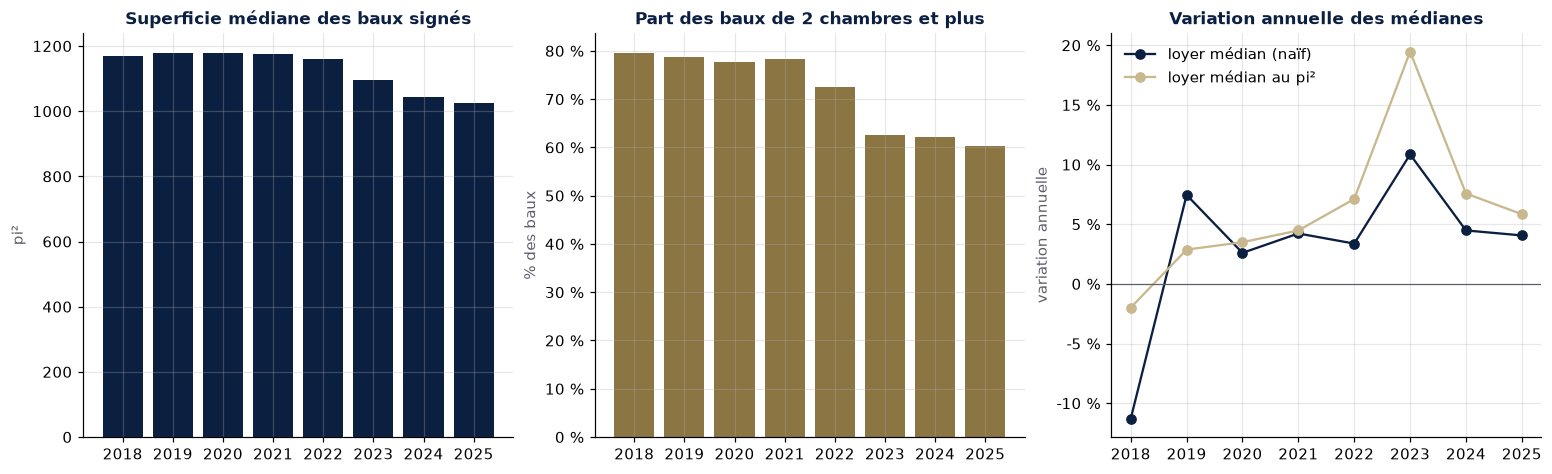

In [12]:
mix_years = mix_table.index
figure, (sqft_axis, large_axis, change_axis) = plt.subplots(
    ncols=3, figsize=WIDE_FIGURE_SIZE, layout="constrained"
)
sqft_axis.bar(mix_years, mix_table["median_sqft"], color=NAVY)
sqft_axis.set(title="Superficie médiane des baux signés", ylabel="pi²")
large_axis.bar(mix_years, mix_table["share_large_pct"], color=BRONZE)
large_axis.set(title=f"Part des baux de {LARGE_UNIT_MIN_BEDROOMS} chambres et plus", ylabel="% des baux")
change_axis.plot(
    mix_years, mix_table["naive_change_pct"], marker="o", color=NAVY, label="loyer médian (naïf)"
)
change_axis.plot(
    mix_years, mix_table["rent_per_sqft_change_pct"], marker="o", color=GOLD, label="loyer médian au pi²"
)
change_axis.axhline(0, color=GREY, linewidth=AXIS_LINE_WIDTH)
change_axis.set(title="Variation annuelle des médianes", ylabel="variation annuelle")
change_axis.legend()
percent_axis(large_axis)
percent_axis(change_axis)
plt.show()

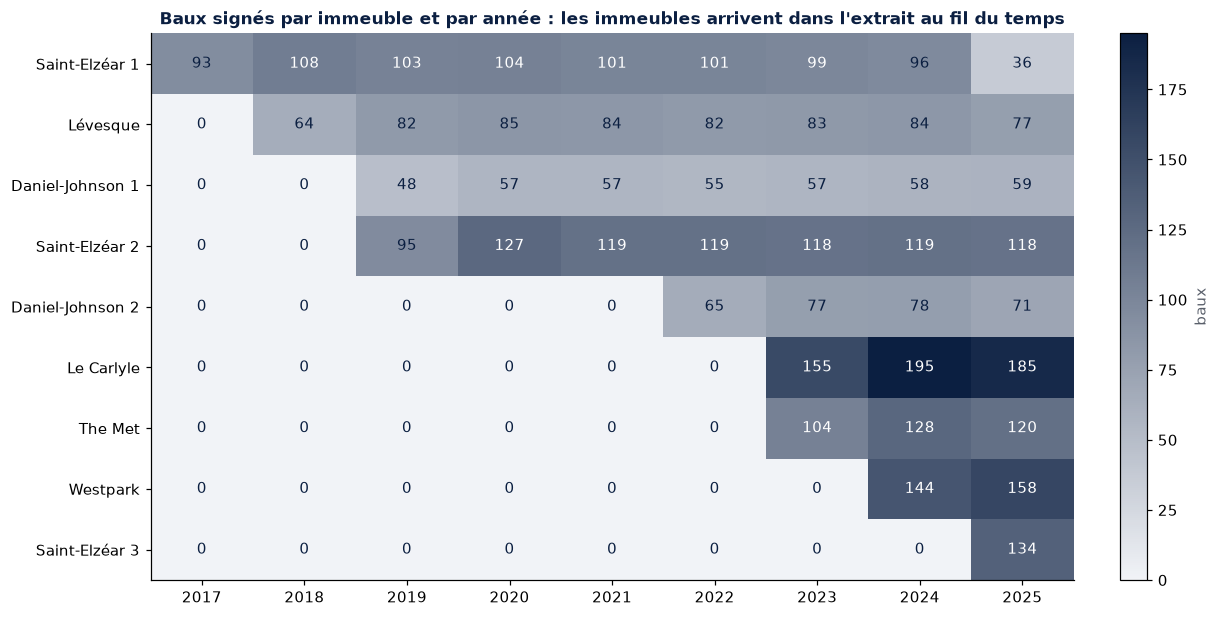

In [13]:
building_order = leases.groupby("building")["lease_start"].min().sort_values().index
leases_by_building_year = leases.pivot_table(
    index="building", columns="year", values="lease_id", aggfunc="size", fill_value=0
).loc[building_order]
text_switch = leases_by_building_year.to_numpy().max() * HEATMAP_TEXT_SWITCH
figure, axis = plt.subplots(figsize=TALL_FIGURE_SIZE, layout="constrained")
image = axis.imshow(leases_by_building_year, cmap=heatmap_colors, aspect="auto")
axis.set_xticks(range(leases_by_building_year.shape[1]), labels=leases_by_building_year.columns)
axis.set_yticks(range(leases_by_building_year.shape[0]), labels=leases_by_building_year.index)
for row_position, building in enumerate(leases_by_building_year.index):
    for column_position, year in enumerate(leases_by_building_year.columns):
        count = leases_by_building_year.loc[building, year]
        axis.text(
            column_position,
            row_position,
            str(count),
            ha="center",
            va="center",
            color="white" if count > text_switch else NAVY,
        )
axis.grid(visible=False)
axis.set_title(
    "Baux signés par immeuble et par année : les immeubles arrivent dans l'extrait au fil du temps"
)
figure.colorbar(image, ax=axis, label="baux")
plt.show()

**Arrivées d'immeubles, location initiale et extrait tronqué.** Le tableau suivant donne, par immeuble, l'année du premier bail et la part des unités dont le dernier bail est terminé avant la date de l'extrait sans bail suivant. Une part élevée signale un extrait tronqué plutôt que des unités vides : on la vérifie avant de mesurer 2025.

In [14]:
units_without_successor = latest_lease[latest_lease["lease_end"] < DATA_AS_OF].groupby("prop_code").size()
building_facts = leases.groupby("prop_code").agg(
    building=("building", "first"), first_lease_year=("year", "min"), units=("unit_id", "nunique")
)
building_facts = building_facts.assign(
    units_without_successor=units_without_successor.reindex(building_facts.index, fill_value=0)
)
building_facts = building_facts.assign(
    share_without_successor_pct=building_facts["units_without_successor"] / building_facts["units"] * PERCENT
).sort_values("first_lease_year")
median_other_share_pct = building_facts.drop(index=TRUNCATED_BUILDING_CODE)[
    "share_without_successor_pct"
].median()
truncated_share_pct = building_facts.loc[TRUNCATED_BUILDING_CODE, "share_without_successor_pct"]
enough_units = building_facts["units_without_successor"] >= MIN_CELL_SIZE
building_facts = building_facts.assign(
    units_without_successor=building_facts["units_without_successor"].where(enough_units).astype("Int64"),
    share_without_successor_pct=building_facts["share_without_successor_pct"].where(enough_units),
)
show_table(building_facts)

lease_up_leases = leases[leases["prop_code"].eq(LEASE_UP_BUILDING_CODE)]
peak_year = mix_table["naive_change_pct"].idxmax()
arrivals = ", ".join(
    f"{row.building} ({row.first_lease_year})"
    for row in building_facts[building_facts["first_lease_year"] > DISPLAY_FIRST_YEAR].itertuples()
)
show_markdown(
    f"- **Médiane naïve.** Sa plus forte hausse est en {peak_year} : "
    f"{fr_pct(mix_table.loc[peak_year, 'naive_change_pct'])}, l'année où la superficie médiane passe de "
    f"{fr_number(mix_table.loc[peak_year - 1, 'median_sqft'], 0)} à "
    f"{fr_number(mix_table.loc[peak_year, 'median_sqft'], 0)} pi² et où la part des "
    f"{LARGE_UNIT_MIN_BEDROOMS} "
    f"chambres et plus passe de "
    f"{fr_pct(mix_table.loc[peak_year - 1, 'share_large_pct'], 0)} à "
    f"{fr_pct(mix_table.loc[peak_year, 'share_large_pct'], 0)}. Des logements plus petits mais plus chers au "
    "pi² "
    f"entrent dans le calcul : la médiane mesure la composition, pas la hausse vécue par un locataire.\n"
    f"- **Immeubles arrivés après {DISPLAY_FIRST_YEAR}** : {arrivals}.\n"
    f"- **{BUILDING_NAMES[LEASE_UP_BUILDING_CODE]} est en location initiale** : "
    f"{fr_pct(lease_up_leases['unit_lease_rank'].eq(1).mean() * PERCENT, 0)} de ses baux sont le premier "
    "bail "
    f"de l'unité : il n'a presque pas de bail précédent à comparer (section 7.6).\n"
    f"- **{BUILDING_NAMES[TRUNCATED_BUILDING_CODE]} est tronqué en {LAST_DATA_YEAR}** : "
    f"{fr_pct(truncated_share_pct, 0)} de ses unités ont un "
    f"dernier bail terminé sans bail suivant, contre "
    f"{fr_pct(median_other_share_pct, 0)} pour l'immeuble médian. "
    f"Ses paires {LAST_DATA_YEAR} sont gardées; la section 7 mesure l'effet de les retirer."
)

immeuble,premier bail,unités,unités dont le dernier bail est terminé sans bail suivant,part de ces unités (%)
Saint-Elzéar 1,2017,106,67,"63,21"
Lévesque,2018,84,5,"5,95"
Saint-Elzéar 2,2019,122,masqué (moins de 5),masqué (moins de 5)
Daniel-Johnson 1,2019,58,masqué (moins de 5),masqué (moins de 5)
Daniel-Johnson 2,2022,76,masqué (moins de 5),masqué (moins de 5)
Le Carlyle,2023,192,masqué (moins de 5),masqué (moins de 5)
The Met,2023,124,masqué (moins de 5),masqué (moins de 5)
Westpark,2024,166,masqué (moins de 5),masqué (moins de 5)
Saint-Elzéar 3,2025,133,masqué (moins de 5),masqué (moins de 5)


- **Médiane naïve.** Sa plus forte hausse est en 2023 : 10,85 %, l'année où la superficie médiane passe de 1 160 à 1 095 pi² et où la part des 2 chambres et plus passe de 73 % à 63 %. Des logements plus petits mais plus chers au pi² entrent dans le calcul : la médiane mesure la composition, pas la hausse vécue par un locataire.
- **Immeubles arrivés après 2018** : Saint-Elzéar 2 (2019), Daniel-Johnson 1 (2019), Daniel-Johnson 2 (2022), Le Carlyle (2023), The Met (2023), Westpark (2024), Saint-Elzéar 3 (2025).
- **Saint-Elzéar 3 est en location initiale** : 99 % de ses baux sont le premier bail de l'unité : il n'a presque pas de bail précédent à comparer (section 7.6).
- **Saint-Elzéar 1 est tronqué en 2025** : 63 % de ses unités ont un dernier bail terminé sans bail suivant, contre 2 % pour l'immeuble médian. Ses paires 2025 sont gardées; la section 7 mesure l'effet de les retirer.

## 3. Hausse à unité constante

### 3.1 Appariement des baux

Chaque bail est comparé au bail précédent de la même unité, sur la clé `sPropCode` + `sUnitCode` (`UNIT_KEY`), jamais sur `sSite` + `sUnitCode`. Pour chaque bail, on copie les valeurs du bail précédent (début, loyers, rabais, durée, concession) et on mesure l'écart, en années, entre les deux débuts de bail. Le tableau classe ces paires selon l'écart.

In [15]:
def build_pairs(lease_rows):
    ordered = lease_rows.sort_values([*UNIT_KEY, "lease_start"])
    previous = (
        ordered.assign(has_concession=ordered["has_concession"].astype(float))
        .groupby(UNIT_KEY)[PREVIOUS_LEASE_COLUMNS]
        .shift()
    )
    paired = ordered.join(previous.add_prefix("prev_"))
    paired = paired[paired["prev_lease_start"].notna()]
    return paired.assign(
        gap_years=(paired["lease_start"] - paired["prev_lease_start"]).dt.days / DAYS_PER_YEAR
    )


all_pairs = build_pairs(leases)
gap_labels = {
    "short": f"{fr_number(MIN_GAP_YEARS, 1)} an ou moins",
    "kept": f"entre {fr_number(MIN_GAP_YEARS, 1)} et {fr_number(MAX_GAP_YEARS, 1)} ans",
    "long": f"{fr_number(MAX_GAP_YEARS, 1)} ans ou plus",
}
gap_class = np.select(
    [all_pairs["gap_years"].le(MIN_GAP_YEARS), all_pairs["gap_years"].ge(MAX_GAP_YEARS)],
    [gap_labels["short"], gap_labels["long"]],
    default=gap_labels["kept"],
)
gap_table = (
    all_pairs.assign(
        gap_class=gap_class,
        gap_days=(all_pairs["lease_start"] - all_pairs["prev_lease_start"]).dt.days,
        after_short_lease=all_pairs["prev_term_months"].lt(MONTHS_PER_YEAR),
    )
    .groupby("gap_class")
    .agg(
        pairs=("lease_id", "size"),
        median_gap_days=("gap_days", "median"),
        after_short_lease_pct=("after_short_lease", "mean"),
    )
    .reindex(list(gap_labels.values()))
)
gap_table = gap_table.assign(
    pairs=gap_table["pairs"].fillna(0).astype(int),
    after_short_lease_pct=gap_table["after_short_lease_pct"] * PERCENT,
)
show_table(gap_table, missing_label="—", hide_index=False)
short_gaps = gap_table.loc[gap_labels["short"]]
show_markdown(
    f"Sous la borne basse : **{int(short_gaps['pairs'])}** paires, dont "
    f"**{fr_pct(short_gaps['after_short_lease_pct'], 0)}** suivent un bail de moins de {MONTHS_PER_YEAR} "
    "mois "
    f"(écart médian de {fr_number(short_gaps['median_gap_days'], 0)} jours). "
    f"Au-delà de la borne haute : **{gap_table.loc[gap_labels['long'], 'pairs']}** paire."
)

,paires,écart médian (jours),part après un bail de moins de 12 mois (%)
écart entre les débuts de bail,,,
"0,5 an ou moins",62,"182,00","100,00"
"entre 0,5 et 2,5 ans",3179,"365,00","0,31"
"2,5 ans ou plus",0,—,—


Sous la borne basse : **62** paires, dont **100 %** suivent un bail de moins de 12 mois (écart médian de 182 jours). Au-delà de la borne haute : **0** paire.

### 3.2 Filtre sur l'écart entre baux et annualisation

Nous gardons les paires dont l'écart est strictement compris entre `MIN_GAP_YEARS` (0,5 an) et `MAX_GAP_YEARS` (2,5 ans).

- **0,5 an ou moins.** Le tableau précédent montre que ces paires suivent un bail court (6 mois). La hausse mesurée sur une demi-année, une fois annualisée, est environ doublée, et elle compare un bail court à un bail d'un an. Ces paires sont exclues.
- **2,5 ans ou plus.** Un tel écart signale un bail manquant ou une longue vacance; l'unité a pu être rénovée et la hausse n'est plus comparable. Le tableau montre si des paires dépassent cette borne; elle reste comme garde-fou.

La hausse annualisée vaut `(loyer / loyer du bail précédent) ^ (1 / écart en années) − 1`. Elle est calculée pour le loyer contractuel et pour le loyer effectif. La fonction `same_unit_growth()` reprend la méthode du notebook de départ, avec les seuils nommés et l'appariement sur `UNIT_KEY`.

In [16]:
def annualized_growth_pct(current, previous, gap_years):
    return ((current / previous) ** (1 / gap_years) - 1) * PERCENT


def same_unit_growth(lease_rows):
    paired = build_pairs(lease_rows)
    kept = paired[paired["gap_years"].between(MIN_GAP_YEARS, MAX_GAP_YEARS, inclusive="neither")]
    return kept.assign(
        contract_growth_pct=annualized_growth_pct(
            kept["contract_rent"], kept["prev_contract_rent"], kept["gap_years"]
        ),
        effective_growth_pct=annualized_growth_pct(
            kept["effective_rent"], kept["prev_effective_rent"], kept["gap_years"]
        ),
    )


pairs = same_unit_growth(leases)
show_table(
    pd.DataFrame(
        [
            {"step": "Baux qui ont un bail précédent dans la même unité", "pairs": len(all_pairs)},
            {"step": "Paires gardées après le filtre sur l'écart", "pairs": len(pairs)},
            {"step": "Unités distinctes dans les paires gardées", "pairs": pairs["unit_id"].nunique()},
        ]
    )
)

étape,paires
Baux qui ont un bail précédent dans la même unité,3241
Paires gardées après le filtre sur l'écart,3179
Unités distinctes dans les paires gardées,890


### 3.3 Hausse à unité constante, année par année

Médiane des hausses annualisées des paires dont le nouveau bail commence dans l'année, pour le loyer contractuel et pour le loyer effectif. Le graphique la compare à la médiane naïve de la section 2.7.

In [17]:
same_unit_by_year = pairs.groupby("year").agg(
    pairs=("lease_id", "size"),
    units=("unit_id", "nunique"),
    contract_pct=("contract_growth_pct", "median"),
    effective_pct=("effective_growth_pct", "median"),
)
same_unit_by_year = mask_small_cells(same_unit_by_year, "pairs", ["contract_pct", "effective_pct"]).loc[
    DISPLAY_FIRST_YEAR:
]
show_table(same_unit_by_year, hide_index=False)

,paires,unités,hausse contractuelle (%),hausse effective (%)
année,,,,
2018,88,88,"2,47","1,98"
2019,159,159,"2,14","1,63"
2020,331,322,"3,17","3,02"
2021,355,355,"4,46","3,54"
2022,352,351,"5,40","4,59"
2023,416,416,"2,29","2,02"
2024,698,678,"3,39","1,77"
2025,780,779,"7,04","3,58"


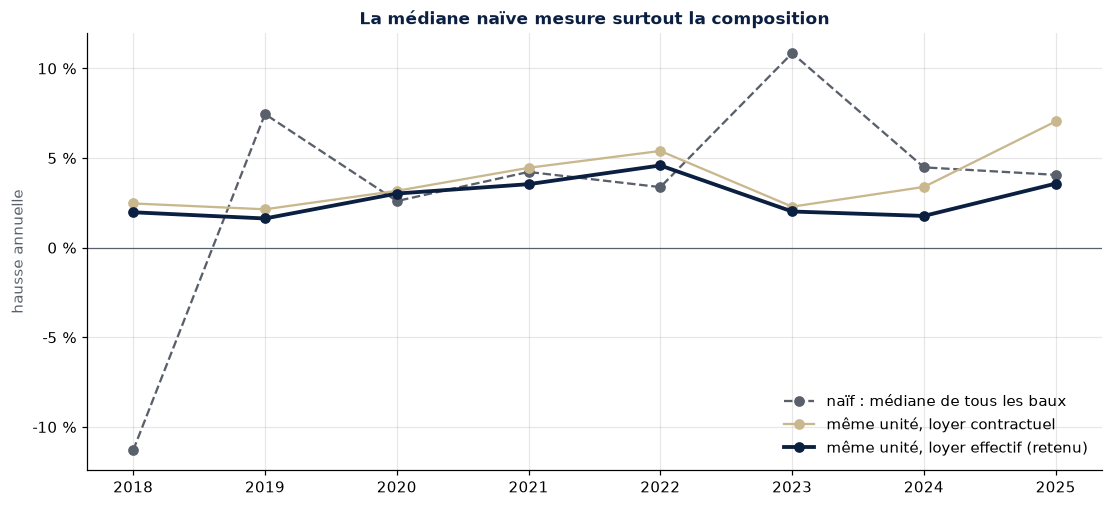

En 2023, la médiane naïve monte de **10,85 %**, alors que les mêmes unités comparées à elles-mêmes montent de **2,29 %** en loyer contractuel et de **2,02 %** en loyer effectif. Sur 2018-2025, l'écart absolu moyen entre la médiane naïve et la hausse effective à unité constante est de 4,18 pp par année.

In [18]:
figure, axis = plt.subplots(figsize=FIGURE_SIZE, layout="constrained")
axis.plot(
    mix_table.index, mix_table["naive_change_pct"], "o--", color=GREY, label="naïf : médiane de tous les baux"
)
axis.plot(
    same_unit_by_year.index,
    same_unit_by_year["contract_pct"],
    "o-",
    color=GOLD,
    label="même unité, loyer contractuel",
)
axis.plot(
    same_unit_by_year.index,
    same_unit_by_year["effective_pct"],
    "o-",
    color=NAVY,
    linewidth=BOLD_LINE_WIDTH,
    label="même unité, loyer effectif (retenu)",
)
axis.axhline(0, color=GREY, linewidth=AXIS_LINE_WIDTH)
axis.set(title="La médiane naïve mesure surtout la composition", ylabel="hausse annuelle")
percent_axis(axis)
axis.legend()
plt.show()

naive_gap = (mix_table["naive_change_pct"] - same_unit_by_year["effective_pct"]).abs()
show_markdown(
    f"En {peak_year}, la médiane naïve monte de **{fr_pct(mix_table.loc[peak_year, 'naive_change_pct'])}**, "
    "alors "
    f"que les mêmes unités comparées à elles-mêmes montent de "
    f"**{fr_pct(same_unit_by_year.loc[peak_year, 'contract_pct'])}** en loyer contractuel et de "
    f"**{fr_pct(same_unit_by_year.loc[peak_year, 'effective_pct'])}** en loyer effectif. "
    f"Sur {DISPLAY_FIRST_YEAR}-{LAST_DATA_YEAR}, l'écart absolu moyen entre la médiane naïve et la hausse "
    "effective "
    f"à unité constante est de {fr_points(naive_gap.mean())} par année."
)

## 4. Concessions : loyer contractuel et loyer effectif

`sRent` est le loyer inscrit au bail (loyer contractuel). `sRentEffective` est le loyer perçu après concessions (loyer effectif).

### 4.1 La formule du loyer effectif

Hypothèse à vérifier : loyer effectif = loyer contractuel + Σ (crédit mensuel × mois de crédit) / durée du bail en mois, en additionnant toutes les concessions du bail. Les crédits sont négatifs, donc le loyer effectif est plus bas. La formule est recalculée pour chaque bail avec concession et comparée à `sRentEffective` au cent près. Pour les baux qui portent une ligne PromoPay de remplissage (section 2.5), nous testons aussi la formule sans ces lignes.

In [19]:
credit_by_lease = concessions.groupby("lease_id")["total_credit"].sum()
credit_without_placeholder = (
    concessions[~concessions["is_placeholder"]].groupby("lease_id")["total_credit"].sum()
)
placeholder_leases = concessions.loc[concessions["is_placeholder"], "lease_id"].unique()
formula_check = leases.loc[
    leases["has_concession"], ["lease_id", "year", "contract_rent", "effective_rent", "term_months"]
]
formula_check = formula_check.assign(
    has_placeholder=formula_check["lease_id"].isin(placeholder_leases),
    formula_rent=formula_check["contract_rent"]
    + formula_check["lease_id"].map(credit_by_lease).fillna(0) / formula_check["term_months"],
    formula_rent_without_placeholder=formula_check["contract_rent"]
    + formula_check["lease_id"].map(credit_without_placeholder).fillna(0) / formula_check["term_months"],
)
formula_check = formula_check.assign(
    matches=(formula_check["formula_rent"] - formula_check["effective_rent"]).abs().lt(RENT_MATCH_TOLERANCE),
    matches_without_placeholder=(
        formula_check["formula_rent_without_placeholder"] - formula_check["effective_rent"]
    )
    .abs()
    .lt(RENT_MATCH_TOLERANCE),
)
with_placeholder = formula_check[formula_check["has_placeholder"]]
without_placeholder = formula_check[~formula_check["has_placeholder"]]
formula_summary = pd.DataFrame(
    [
        {
            "group": "Tous les baux avec concession",
            "leases": len(formula_check),
            "match_pct": formula_check["matches"].mean() * PERCENT,
        },
        {
            "group": "Baux sans ligne PromoPay de remplissage",
            "leases": len(without_placeholder),
            "match_pct": without_placeholder["matches"].mean() * PERCENT,
        },
        {
            "group": "Baux avec une ligne de remplissage, formule complète",
            "leases": len(with_placeholder),
            "match_pct": with_placeholder["matches"].mean() * PERCENT,
        },
        {
            "group": "Baux avec une ligne de remplissage, formule sans ces lignes",
            "leases": len(with_placeholder),
            "match_pct": with_placeholder["matches_without_placeholder"].mean() * PERCENT,
        },
    ]
)
effective_formula_match_pct = without_placeholder["matches"].mean() * PERCENT
show_table(formula_summary)

groupe,baux,formule exacte (%)
Tous les baux avec concession,2719,"85,51"
Baux sans ligne PromoPay de remplissage,2350,"98,94"
"Baux avec une ligne de remplissage, formule complète",369,"0,00"
"Baux avec une ligne de remplissage, formule sans ces lignes",369,"0,00"


### 4.2 Les lignes PromoPay de remplissage

Certaines lignes PromoPay valent exactement −loyer contractuel : un mois entier gratuit inscrit comme crédit. Le tableau 4.1 indique si la formule reproduit le loyer effectif des baux qui les portent, avec ou sans ces lignes. Nous mesurons ensuite le crédit que `sRentEffective` contient vraiment pour ces baux, en plus de leurs autres concessions.

**Le loyer effectif (`sRentEffective`) fait foi** : il est calculé par le CRM, et la formule le reproduit pour presque tous les autres baux (taux exact sous le tableau). Les lignes de remplissage sont rapportées comme un constat sur la qualité des données, sans correction. Le tableau les compte par année de début du bail.

In [20]:
placeholder_by_year = (
    concessions[concessions["is_placeholder"]]
    .groupby("year")
    .size()
    .reindex(range(leases["year"].min(), LAST_DATA_YEAR + 1), fill_value=0)
    .rename("rows")
    .rename_axis("year")
    .reset_index()
)
implied_placeholder_months = (
    (with_placeholder["formula_rent_without_placeholder"] - with_placeholder["effective_rent"])
    * with_placeholder["term_months"]
    / with_placeholder["contract_rent"]
)
regular_promopay_months = -regular_promopay["total_credit"] / regular_promopay["contract_rent"]
show_table(placeholder_by_year)
show_markdown(
    f"- **Lignes de remplissage** : {placeholder_by_year['rows'].sum()} lignes sur {len(with_placeholder)} "
    "baux, "
    f"toutes années de début de bail comprises.\n"
    f"- **Formule du loyer effectif** : elle reproduit `sRentEffective` pour "
    f"**{fr_pct(effective_formula_match_pct)}** des {len(without_placeholder)} baux avec concession sans "
    "ligne de "
    f"remplissage.\n"
    f"- Pour les {len(with_placeholder)} baux concernés, le crédit que `sRentEffective` contient en plus des "
    "autres "
    f"concessions vaut en médiane **{fr_number(implied_placeholder_months.median())} mois** de loyer "
    "contractuel "
    f"(positif pour {fr_pct(implied_placeholder_months.gt(0).mean() * PERCENT, 0)} de ces baux). C'est "
    "l'ordre de "
    f"grandeur d'une ligne PromoPay ordinaire ({fr_number(regular_promopay_months.median())} mois en "
    "médiane), pas le "
    "mois entier inscrit : la ligne de remplissage a remplacé le vrai montant du rabais, que seul "
    "`sRentEffective` "
    f"conserve."
)

année,lignes
2017,5
2018,8
2019,23
2020,22
2021,33
2022,29
2023,52
2024,88
2025,120


- **Lignes de remplissage** : 380 lignes sur 369 baux, toutes années de début de bail comprises.
- **Formule du loyer effectif** : elle reproduit `sRentEffective` pour **98,94 %** des 2350 baux avec concession sans ligne de remplissage.
- Pour les 369 baux concernés, le crédit que `sRentEffective` contient en plus des autres concessions vaut en médiane **0,69 mois** de loyer contractuel (positif pour 100 % de ces baux). C'est l'ordre de grandeur d'une ligne PromoPay ordinaire (0,67 mois en médiane), pas le mois entier inscrit : la ligne de remplissage a remplacé le vrai montant du rabais, que seul `sRentEffective` conserve.

### 4.3 Fréquence et taille des concessions

Pour les baux signés chaque année : la part des baux avec concession (fréquence) et le rabais moyen de ces baux, en % du loyer contractuel (taille). Le rabais d'un bail vaut `1 − loyer effectif / loyer contractuel`.

In [21]:
concession_by_year = (
    leases[leases["year"].between(DISPLAY_FIRST_YEAR, LAST_DATA_YEAR)]
    .assign(discount_when_conceded=leases["discount_pct"].where(leases["has_concession"]))
    .groupby("year")
    .agg(
        leases=("lease_id", "size"),
        share_with_concession_pct=("has_concession", "mean"),
        average_discount_pct=("discount_when_conceded", "mean"),
        mean_discount_all_pct=("discount_pct", "mean"),
    )
)
concession_by_year = concession_by_year.assign(
    share_with_concession_pct=concession_by_year["share_with_concession_pct"] * PERCENT
)
show_table(concession_by_year, hide_index=False)

,baux,baux avec concession (%),rabais moyen quand concession (%),"rabais moyen, tous baux (%)"
année,,,,
2018,172,"38,37","3,53","1,36"
2019,328,"44,21","3,85","1,70"
2020,373,"48,79","4,28","2,09"
2021,361,"54,02","4,98","2,69"
2022,422,"57,35","5,80","3,33"
2023,693,"54,26","6,59","3,58"
2024,902,"73,06","7,81","5,71"
2025,958,"85,39","10,69","9,13"


### 4.4 Pourquoi les hausses contractuelle et effective divergent

Pour les paires d'une année, l'écart entre la hausse contractuelle et la hausse effective vient de la variation du rabais entre le bail précédent et le nouveau bail. Le rabais moyen d'un groupe de baux est le produit de deux facteurs : la part des baux avec concession (fréquence) et le rabais moyen de ces baux (taille). Sa variation se décompose exactement en deux parts :
- **fréquence** = variation de la part × taille moyenne des deux baux;
- **taille** = variation de la taille × part moyenne des deux baux.

In [22]:
def discount_decomposition(pair_rows):
    previous_conceded = pair_rows["prev_has_concession"].eq(1)
    by_year = (
        pair_rows.assign(
            prev_conceded=previous_conceded,
            prev_size=pair_rows["prev_discount_pct"].where(previous_conceded),
            new_size=pair_rows["discount_pct"].where(pair_rows["has_concession"]),
        )
        .groupby("year")
        .agg(
            share_prev=("prev_conceded", "mean"),
            share_new=("has_concession", "mean"),
            size_prev_pct=("prev_size", "mean"),
            size_new_pct=("new_size", "mean"),
            contract_pct=("contract_growth_pct", "median"),
            effective_pct=("effective_growth_pct", "median"),
        )
    )
    return pd.DataFrame(
        {
            "share_prev_pct": by_year["share_prev"] * PERCENT,
            "share_new_pct": by_year["share_new"] * PERCENT,
            "size_prev_pct": by_year["size_prev_pct"],
            "size_new_pct": by_year["size_new_pct"],
            "total_pp": by_year["share_new"] * by_year["size_new_pct"]
            - by_year["share_prev"] * by_year["size_prev_pct"],
            "frequency_pp": (by_year["share_new"] - by_year["share_prev"])
            * midpoint(by_year["size_new_pct"], by_year["size_prev_pct"]),
            "size_pp": (by_year["size_new_pct"] - by_year["size_prev_pct"])
            * midpoint(by_year["share_new"], by_year["share_prev"]),
            "growth_gap_pp": by_year["contract_pct"] - by_year["effective_pct"],
        }
    )


decomposition = discount_decomposition(pairs).loc[DISPLAY_FIRST_YEAR:]
show_table(decomposition, hide_index=False)

,"part avec concession, bail précédent (%)","part avec concession, nouveau bail (%)","rabais moyen, bail précédent (%)","rabais moyen, nouveau bail (%)",variation du rabais moyen (pp),part fréquence (pp),part taille (pp),écart hausse contractuelle − effective (pp)
année,,,,,,,,
2018,"39,77","37,50","3,04","3,62","0,15","-0,08","0,22","0,49"
2019,"38,36","47,17","3,54","3,77","0,42","0,32","0,10","0,51"
2020,"45,92","48,34","3,84","4,28","0,30","0,10","0,20","0,15"
2021,"47,04","53,80","4,29","4,99","0,66","0,31","0,35","0,91"
2022,"55,68","57,95","4,92","5,78","0,61","0,12","0,49","0,81"
2023,"55,29","48,80","5,81","6,64","0,03","-0,40","0,43","0,27"
2024,"55,30","70,06","6,63","7,79","1,79","1,06","0,73","1,62"
2025,"74,23","86,41","7,79","10,70","3,46","1,13","2,33","3,47"


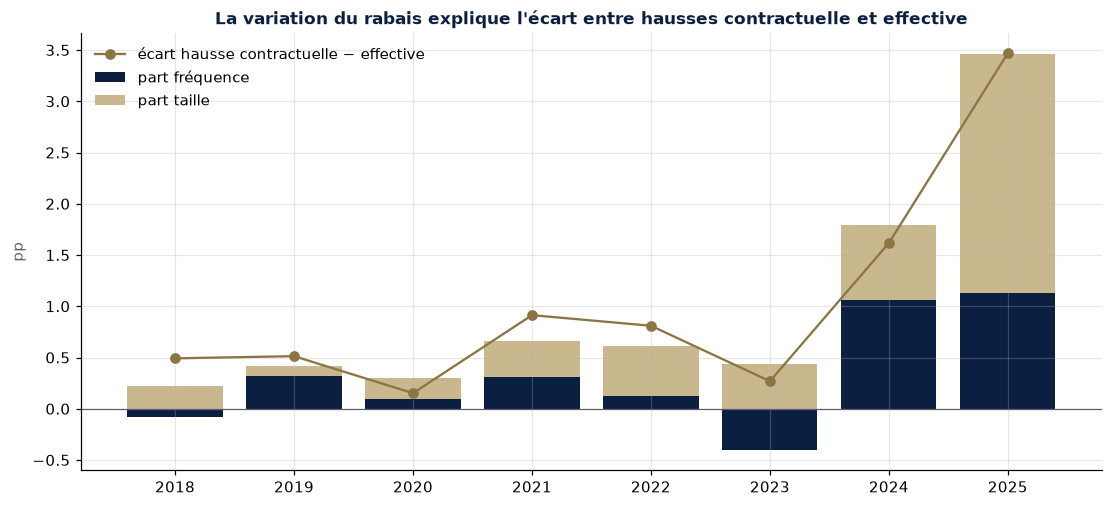

- **2024** : le rabais moyen varie de +1,79 pp (fréquence +1,06 pp, taille +0,73 pp) : surtout **des concessions plus fréquentes**. La part des baux avec concession passe de 55 % à 70 %; le rabais de ces baux passe de 6,6 % à 7,8 %. Écart entre hausses contractuelle et effective : +1,62 pp.
- **2025** : le rabais moyen varie de +3,46 pp (fréquence +1,13 pp, taille +2,33 pp) : surtout **des concessions plus grosses**. La part des baux avec concession passe de 74 % à 86 %; le rabais de ces baux passe de 7,8 % à 10,7 %. Écart entre hausses contractuelle et effective : +3,47 pp.

In [23]:
figure, axis = plt.subplots(figsize=FIGURE_SIZE, layout="constrained")
axis.bar(decomposition.index, decomposition["frequency_pp"], color=NAVY, label="part fréquence")
axis.bar(
    decomposition.index,
    decomposition["size_pp"],
    bottom=decomposition["frequency_pp"].clip(lower=0),
    color=GOLD,
    label="part taille",
)
axis.plot(
    decomposition.index,
    decomposition["growth_gap_pp"],
    "o-",
    color=BRONZE,
    label="écart hausse contractuelle − effective",
)
axis.axhline(0, color=GREY, linewidth=AXIS_LINE_WIDTH)
axis.set(
    title="La variation du rabais explique l'écart entre hausses contractuelle et effective", ylabel="pp"
)
axis.legend()
plt.show()


def describe_discount_change(row, year):
    driver = (
        "des concessions plus fréquentes"
        if row["frequency_pp"] > row["size_pp"]
        else "des concessions plus grosses"
    )
    return (
        f"- **{year}** : le rabais moyen varie de {fr_pp(row['total_pp'])} (fréquence "
        f"{fr_pp(row['frequency_pp'])}, "
        f"taille {fr_pp(row['size_pp'])}) : surtout **{driver}**. La part des baux avec concession passe de "
        f"{fr_pct(row['share_prev_pct'], 0)} à {fr_pct(row['share_new_pct'], 0)}; le rabais de ces baux "
        "passe de "
        f"{fr_pct(row['size_prev_pct'], 1)} à {fr_pct(row['size_new_pct'], 1)}. Écart entre hausses "
        "contractuelle "
        f"et effective : {fr_pp(row['growth_gap_pp'])}."
    )


recent_years = [LAST_DATA_YEAR - 1, LAST_DATA_YEAR]
show_markdown("\n".join(describe_discount_change(decomposition.loc[year], year) for year in recent_years))

**Ce que cela veut dire pour un propriétaire.** Le loyer contractuel continue de monter au rythme du marché et des règles, mais une part croissante de cette hausse est rendue aux locataires en concessions. Le loyer contractuel décrit le prix inscrit au bail; le loyer effectif décrit les revenus. Pour budgéter, c'est la hausse du loyer effectif qu'il faut citer. Pour suivre les règles (TAL, ligne directrice de l'Ontario), c'est le loyer contractuel. Les deux sont publiés.

### 4.5 Les codes de concession et leur traitement

Pour chaque code : nombre de lignes, durée médiane du crédit et crédit mensuel médian en % du loyer contractuel du bail (lignes de remplissage exclues des médianes). Tous les codes, y compris les avantages accessoires, entrent dans `sRentEffective` : c'est ce que vérifie la formule de la section 4.1. Nous gardons ce traitement, puisque `sRentEffective` fait foi.

In [24]:
concession_labels = {
    "PromoPay": "Rabais promotionnel",
    "freerent": "Loyer gratuit",
    "freepark": "Stationnement gratuit",
    "freelock": "Casier gratuit",
    "freeappl": "Électroménagers gratuits",
    "Freeothe": "Autre avantage",
    "Indem": "Indemnité au résident",
    "Referenc": "Crédit de référencement",
}
concession_treatments = {
    "PromoPay": "Crédit ponctuel étalé sur le bail dans sRentEffective; lignes de remplissage non reprises",
    "freerent": "Inclus dans sRentEffective, étalé sur la durée du bail",
    "freepark": "Accessoire, inclus par le CRM dans sRentEffective",
    "freelock": "Accessoire, inclus par le CRM dans sRentEffective",
    "freeappl": "Accessoire, inclus par le CRM dans sRentEffective",
    "Freeothe": "Inclus dans sRentEffective",
    "Indem": "Inclus dans sRentEffective",
    "Referenc": "Inclus dans sRentEffective",
}
regular_rows = concessions[~concessions["is_placeholder"]]
concession_codes = (
    concessions.groupby("charge_code")
    .agg(rows=("monthly_credit", "size"))
    .join(
        regular_rows.groupby("charge_code").agg(
            median_months=("credit_months", "median"),
            median_share_of_rent_pct=("share_of_rent_pct", "median"),
        )
    )
    .sort_values("rows", ascending=False)
)
concession_codes = concession_codes.assign(
    code=concession_codes.index,
    label=concession_codes.index.map(concession_labels),
    treatment=concession_codes.index.map(concession_treatments),
)[["code", "label", "rows", "median_months", "median_share_of_rent_pct", "treatment"]]
show_table(concession_codes)

code,libellé,lignes,mois de crédit (médiane),crédit mensuel en % du loyer (médiane),traitement
PromoPay,Rabais promotionnel,1494,"1,00","57,76",Crédit ponctuel étalé sur le bail dans sRentEffective; lignes de remplissage non reprises
freepark,Stationnement gratuit,1006,"12,00","7,58","Accessoire, inclus par le CRM dans sRentEffective"
Freeothe,Autre avantage,570,"12,00","7,67",Inclus dans sRentEffective
freelock,Casier gratuit,175,"12,00","7,04","Accessoire, inclus par le CRM dans sRentEffective"
freerent,Loyer gratuit,166,"12,00","7,26","Inclus dans sRentEffective, étalé sur la durée du bail"
Indem,Indemnité au résident,69,"12,00","6,38",Inclus dans sRentEffective
freeappl,Électroménagers gratuits,44,"12,00","8,47","Accessoire, inclus par le CRM dans sRentEffective"
Referenc,Crédit de référencement,36,"12,00","7,98",Inclus dans sRentEffective


## 5. Renouvellements et relocations, Québec et Ontario

`sRenewal = 1` : un locataire en place renouvelle. `sRenewal = 0` : l'unité change de locataire (relocation). Les règles diffèrent selon le cas et selon la province :

- **Québec (TAL).** Au renouvellement, le locataire peut refuser la hausse proposée; le propriétaire peut alors demander au TAL de fixer le loyer, qui le calcule à partir de paramètres annuels. Le taux de référence n'est donc pas un plafond, mais c'est le repère connu de tous en janvier. Dans un immeuble construit depuis 5 ans ou moins, la section F du bail s'applique : le locataire ne peut pas demander au TAL de fixer le loyer. À la relocation, le loyer est libre; le nouveau locataire peut contester un loyer supérieur au plus bas loyer des 12 derniers mois, sauf en section F.
- **Ontario (ligne directrice).** Au renouvellement, la hausse est plafonnée par la ligne directrice, sauf pour un logement occupé pour la première fois après le 15 novembre 2018. Au changement de locataire, le loyer est libre.
- **Le plafond d'une province n'est jamais appliqué à l'autre.** Les relocations ne sont plafonnées dans aucune des deux provinces.

### 5.1 Segments par année et par province

Médianes des hausses annualisées à unité constante, par année, province et segment. « — » signifie aucune paire, ou moins de 5 paires (case masquée).

In [25]:
segment_by_year = pairs.groupby(["year", *SEGMENT_COLUMNS]).agg(
    pairs=("lease_id", "size"),
    contract_pct=("contract_growth_pct", "median"),
    effective_pct=("effective_growth_pct", "median"),
)
segment_by_year = (
    mask_small_cells(segment_by_year, "pairs", ["contract_pct", "effective_pct"])
    .loc[DISPLAY_FIRST_YEAR:]
    .reset_index()
)
segment_view = segment_by_year.pivot(
    index="year", columns=SEGMENT_COLUMNS, values=["pairs", "contract_pct", "effective_pct"]
)
segment_view["pairs"] = segment_view["pairs"].astype("Int64")
show_table(segment_view, missing_label="—", hide_index=False)

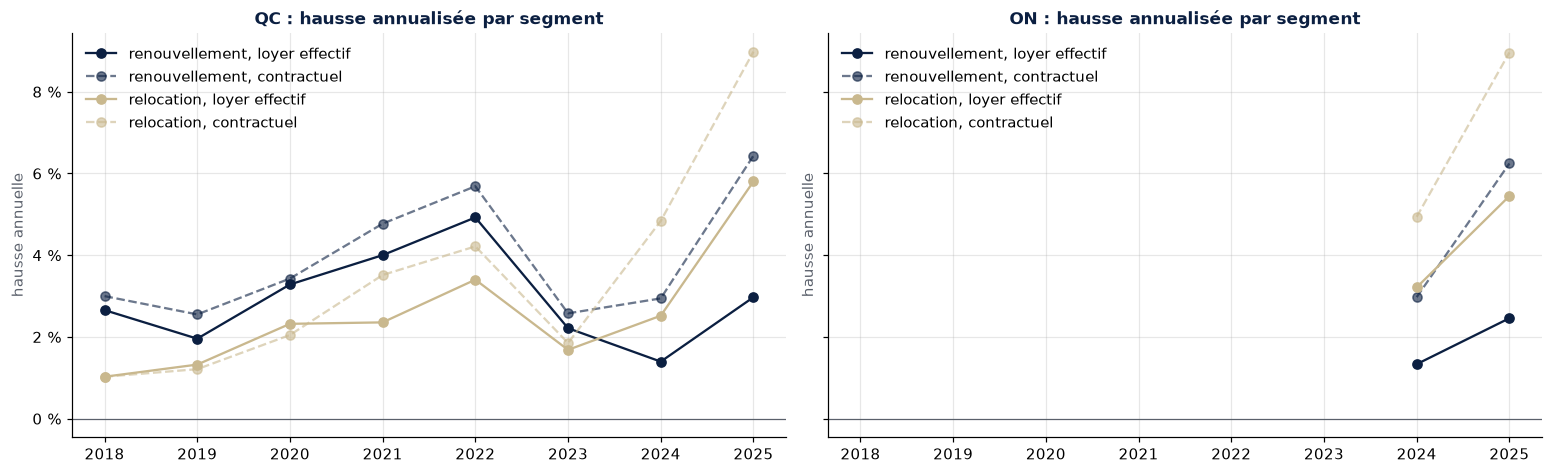

In [26]:
segment_styles = {RENEWAL: NAVY, RELOCATION: GOLD}
figure, province_axes = plt.subplots(
    ncols=2, figsize=WIDE_FIGURE_SIZE, layout="constrained", sharey=True, sharex=True
)
for axis, province in zip(province_axes, [QUEBEC, ONTARIO], strict=True):
    axis.set_xticks(DISPLAY_YEARS)
    for segment, color in segment_styles.items():
        rows = segment_by_year[
            segment_by_year["province"].eq(province) & segment_by_year["segment"].eq(segment)
        ]
        axis.plot(rows["year"], rows["effective_pct"], "o-", color=color, label=f"{segment}, loyer effectif")
        axis.plot(
            rows["year"],
            rows["contract_pct"],
            "o--",
            color=color,
            alpha=SECONDARY_ALPHA,
            label=f"{segment}, contractuel",
        )
    axis.axhline(0, color=GREY, linewidth=AXIS_LINE_WIDTH)
    axis.set(title=f"{province} : hausse annualisée par segment", ylabel="hausse annuelle")
    percent_axis(axis)
    axis.legend()
plt.show()

### 5.2 Le régime de chaque immeuble

Les deux petits fichiers de règles (taux du TAL, ligne directrice de l'Ontario) sont chargés ici; ils sont détaillés à la section 6.1.

L'âge d'un immeuble est mesuré depuis son premier bail dans l'extrait. C'est une approximation de la date de construction : Saint-Elzéar 1 a des baux dès le début de l'extrait et peut être plus ancien. Le régime des renouvellements est déterminé pour l'année 2026. Pour vérifier les régimes, le tableau compare les renouvellements 2025 de chaque immeuble au repère de sa province (taux du TAL au Québec, ligne directrice en Ontario).

In [27]:
tal_rates = pd.read_csv(TAL_FILE)
ontario_guideline = pd.read_csv(ONTARIO_FILE)


def renewal_regime(province, building_age, first_lease_start):
    if province == ONTARIO:
        return (
            REGIME_ONTARIO_EXEMPT if first_lease_start > ONTARIO_EXEMPTION_DATE else REGIME_ONTARIO_GUIDELINE
        )
    if building_age > NEW_BUILDING_MAX_AGE_YEARS:
        return REGIME_TAL
    return REGIME_SECTION_F


def building_regimes_for(lease_history, target_year):
    buildings = lease_history.groupby("prop_code").agg(
        province=("province", "first"), first_lease_start=("lease_start", "min")
    )
    ages = target_year - buildings["first_lease_start"].dt.year
    return pd.Series(
        [
            renewal_regime(province, age, start)
            for province, age, start in zip(
                buildings["province"], ages, buildings["first_lease_start"], strict=True
            )
        ],
        index=buildings.index,
    )


benchmarks = {
    QUEBEC: tal_rates.set_index("year").loc[LAST_DATA_YEAR, "tal_pct"],
    ONTARIO: ontario_guideline.set_index("year").loc[LAST_DATA_YEAR, "guideline_pct"],
}
last_year_renewals = pairs[pairs["is_renewal"] & pairs["year"].eq(LAST_DATA_YEAR)]
last_year_renewals = last_year_renewals.assign(benchmark_pct=last_year_renewals["province"].map(benchmarks))
renewal_evidence = (
    last_year_renewals.assign(
        above_benchmark=last_year_renewals["contract_growth_pct"] > last_year_renewals["benchmark_pct"]
    )
    .groupby("prop_code")
    .agg(
        renewal_pairs=("lease_id", "size"),
        renewal_contract_pct=("contract_growth_pct", "median"),
        benchmark_pct=("benchmark_pct", "first"),
        above_benchmark_pct=("above_benchmark", "mean"),
    )
)
renewal_evidence = renewal_evidence.assign(
    above_benchmark_pct=renewal_evidence["above_benchmark_pct"] * PERCENT
)
building_regimes = leases.groupby("prop_code").agg(
    name=("building", "first"),
    city=("city", "first"),
    province=("province", "first"),
    first_lease_year=("year", "min"),
)
building_regimes = building_regimes.assign(
    age_in_forecast_year=FORECAST_YEAR - building_regimes["first_lease_year"],
    regime=building_regimes_for(leases, FORECAST_YEAR),
).join(renewal_evidence)
building_regimes = building_regimes.assign(
    renewal_pairs=building_regimes["renewal_pairs"].fillna(0).astype(int)
).sort_values(["province", "first_lease_year"], ascending=[False, True])
building_regimes = mask_small_cells(
    building_regimes, "renewal_pairs", ["renewal_contract_pct", "benchmark_pct", "above_benchmark_pct"]
)
show_table(building_regimes.drop(columns="city"))

nom,province,premier bail,âge en 2026 (ans),régime des renouvellements en 2026,renouvellements 2025,hausse contractuelle médiane des renouvellements 2025 (%),"repère 2025 (TAL ou ligne directrice, %)",renouvellements au-dessus du repère (%)
Saint-Elzéar 1,QC,2017,9,TAL : taux de référence (immeuble de plus de 5 ans),21,"6,47","5,90","61,90"
Lévesque,QC,2018,8,TAL : taux de référence (immeuble de plus de 5 ans),47,"6,24","5,90","65,96"
Daniel-Johnson 1,QC,2019,7,TAL : taux de référence (immeuble de plus de 5 ans),34,"6,55","5,90","73,53"
Saint-Elzéar 2,QC,2019,7,TAL : taux de référence (immeuble de plus de 5 ans),76,"6,76","5,90","69,74"
Daniel-Johnson 2,QC,2022,4,"Section F : immeuble de 5 ans ou moins, loyer non fixé par le TAL",38,"6,32","5,90","65,79"
Le Carlyle,QC,2023,3,"Section F : immeuble de 5 ans ou moins, loyer non fixé par le TAL",115,"6,40","5,90","67,83"
Westpark,QC,2024,2,"Section F : immeuble de 5 ans ou moins, loyer non fixé par le TAL",79,"6,25","5,90","60,76"
Saint-Elzéar 3,QC,2025,1,"Section F : immeuble de 5 ans ou moins, loyer non fixé par le TAL",0,masqué (moins de 5),masqué (moins de 5),masqué (moins de 5)
The Met,ON,2023,3,Ontario : exemptée de la ligne directrice (premier bail après le 2018-11-15),63,"6,25","2,50","100,00"


In [28]:
the_met = building_regimes.loc[THE_MET_CODE]
tal_buildings = last_year_renewals[
    last_year_renewals["prop_code"].map(building_regimes_for(leases, LAST_DATA_YEAR)).eq(REGIME_TAL)
]
exemption_reading = (
    "Ce ne serait pas permis sous la ligne directrice : The Met est bien exemptée"
    if the_met["above_benchmark_pct"] > 0
    else "Les renouvellements restent sous la ligne directrice, mais The Met en est exemptée"
)
show_markdown(
    f"- **The Met** : {fr_pct(the_met['above_benchmark_pct'], 0)} des renouvellements {LAST_DATA_YEAR} "
    "dépassent "
    f"la ligne directrice de {fr_pct(benchmarks[ONTARIO], 1)} (hausse contractuelle médiane "
    f"{fr_pct(the_met['renewal_contract_pct'])}). {exemption_reading}, son premier bail datant de "
    f"{the_met['first_lease_year']}, après le {ONTARIO_EXEMPTION_DATE.date()}. "
    f"La ligne directrice ne sert donc pas de repère pour sa prévision.\n"
    f"- **Immeubles québécois soumis au TAL en {LAST_DATA_YEAR}** ({tal_buildings['prop_code'].nunique()} "
    "immeubles, "
    f"{len(tal_buildings)} renouvellements) : hausse contractuelle médiane de "
    f"{fr_pct(tal_buildings['contract_growth_pct'].median())}, pour un taux de référence du TAL de "
    f"{fr_pct(benchmarks[QUEBEC], 1)}. Le taux du TAL est un repère, pas un plafond.\n"
    f"- **Immeubles en section F** : le TAL ne fixe pas leur loyer; leurs renouvellements suivent le marché."
)

- **The Met** : 100 % des renouvellements 2025 dépassent la ligne directrice de 2,5 % (hausse contractuelle médiane 6,25 %). Ce ne serait pas permis sous la ligne directrice : The Met est bien exemptée, son premier bail datant de 2023, après le 2018-11-15. La ligne directrice ne sert donc pas de repère pour sa prévision.
- **Immeubles québécois soumis au TAL en 2025** (4 immeubles, 178 renouvellements) : hausse contractuelle médiane de 6,54 %, pour un taux de référence du TAL de 5,9 %. Le taux du TAL est un repère, pas un plafond.
- **Immeubles en section F** : le TAL ne fixe pas leur loyer; leurs renouvellements suivent le marché.

### 5.3 Les cinq définitions candidates, mesurées

Les définitions de la section 1, calculées sur les mêmes années, avec la version pondérée en dollars : `Σ loyer effectif précédent × (1 + hausse) / Σ loyer effectif précédent − 1`, soit la hausse des revenus des unités comparées.

In [29]:
def dollar_weighted_growth_pct(rows, growth_column, weight_column):
    weights = rows[weight_column]
    return ((weights * (1 + rows[growth_column] / PERCENT)).sum() / weights.sum() - 1) * PERCENT


segment_medians = pairs.groupby(["year", "segment"])["effective_growth_pct"].median().unstack()
definitions = pd.DataFrame(
    {
        "Portefeuille global, médiane naïve": mix_table["naive_change_pct"],
        "Même unité, loyer contractuel": same_unit_by_year["contract_pct"],
        "Même unité, loyer effectif (retenue)": same_unit_by_year["effective_pct"],
        "Renouvellements seulement, effectif": segment_medians[RENEWAL],
        "Relocations seulement, effectif": segment_medians[RELOCATION],
        "Même unité, effectif pondéré en dollars": pd.Series(
            {
                year: dollar_weighted_growth_pct(group, "effective_growth_pct", "prev_effective_rent")
                for year, group in pairs.groupby("year")
            }
        ),
    }
).loc[BACKTEST_FIRST_YEAR:LAST_DATA_YEAR]
show_table(
    definitions.rename_axis("year"),
    hide_index=False,
    highlight_columns=["Même unité, loyer effectif (retenue)"],
)
show_markdown(
    f"Sur {BACKTEST_FIRST_YEAR}-{LAST_DATA_YEAR}, la plus haute et la plus basse des définitions s'écartent "
    "en "
    f"moyenne de {fr_points((definitions.max(axis=1) - definitions.min(axis=1)).mean())} par année : il faut "
    f"nommer celle qu'on prévoit."
)

,"Portefeuille global, médiane naïve","Même unité, loyer contractuel","Même unité, loyer effectif (retenue)","Renouvellements seulement, effectif","Relocations seulement, effectif","Même unité, effectif pondéré en dollars"
année,,,,,,
2021,"4,23","4,46","3,54","4,00","2,36","3,65"
2022,"3,38","5,40","4,59","4,92","3,40","4,63"
2023,"10,85","2,29","2,02","2,21","1,68","2,18"
2024,"4,48","3,39","1,77","1,38","2,75","1,79"
2025,"4,06","7,04","3,58","2,91","5,74","3,62"


Sur 2021-2025, la plus haute et la plus basse des définitions s'écartent en moyenne de 4,10 pp par année : il faut nommer celle qu'on prévoit.

## 6. Données publiques et signaux internes

### 6.1 Règles : TAL et ligne directrice de l'Ontario

Les deux fichiers ont été recopiés des pages officielles, avec l'adresse de la source sur chaque ligne (section 9). Pour le TAL, la valeur 2026 suit la nouvelle méthode de calcul (pourcentage de base, moyenne de l'IPC du Québec sur trois ans) : la série est rompue, la colonne « méthode TAL » le signale. Le taux est connu en janvier de l'année visée; la ligne directrice de l'Ontario est publiée l'été précédent.

In [30]:
rules = tal_rates[["year", "tal_pct", "tal_method"]].merge(
    ontario_guideline[["year", "guideline_pct", "note"]], on="year", how="outer"
)
show_table(rules, missing_label="—")

année,taux TAL (%),méthode TAL,ligne directrice Ontario (%),note
2017,"0,60",ancienne méthode — logement non chauffé,"1,50",ligne directrice annuelle
2018,"0,50",ancienne méthode — logement non chauffé,"1,80",ligne directrice annuelle
2019,"0,50",ancienne méthode — logement non chauffé,"1,80",ligne directrice annuelle
2020,"1,20",ancienne méthode — logement non chauffé,"2,20",ligne directrice annuelle
2021,"0,80",ancienne méthode — logement non chauffé,"0,00",gel des loyers
2022,"1,28",ancienne méthode — logement non chauffé,"1,20",ligne directrice annuelle
2023,"2,30",ancienne méthode — logement non chauffé,"2,50",ligne directrice annuelle
2024,"4,00",ancienne méthode — logement non chauffé,"2,50",ligne directrice annuelle
2025,"5,90",ancienne méthode — logement non chauffé,"2,50",ligne directrice annuelle
2026,"3,10",nouvelle méthode — pourcentage de base,"2,10",ligne directrice annuelle


### 6.2 IPC de Statistique Canada (tableau 18-10-0004-01)

Le fichier compressé fourni est lu par morceaux et filtré sur quatre séries (vecteurs) : loyers au Québec et en Ontario, ensemble des biens et services au Québec et en Ontario. Les mois postérieurs à la date de l'extrait sont exclus. La variation annuelle compare les moyennes des douze mois de deux années consécutives.

In [31]:
def read_cpi_series(zip_path=CPI_ZIP_FILE):
    with zipfile.ZipFile(zip_path) as archive, archive.open(CPI_CSV_NAME) as handle:
        chunks = [
            chunk[chunk["VECTOR"].isin(CPI_SERIES["vector"])]
            for chunk in pd.read_csv(handle, usecols=CPI_COLUMNS, dtype=str, chunksize=CPI_CHUNK_ROWS)
        ]
    return pd.concat(chunks, ignore_index=True).merge(CPI_SERIES, left_on="VECTOR", right_on="vector")


def annual_cpi_changes(cpi_rows):
    monthly = cpi_rows.assign(
        month=pd.to_datetime(cpi_rows["REF_DATE"]), value=pd.to_numeric(cpi_rows["VALUE"])
    )
    monthly = monthly[monthly["month"] <= DATA_AS_OF]
    annual = (
        monthly.assign(year=monthly["month"].dt.year)
        .groupby(["series", "province", "year"])
        .agg(index_mean=("value", "mean"), months=("value", "size"))
        .reset_index()
    )
    annual = annual[annual["months"] == MONTHS_PER_YEAR]
    return annual.assign(
        change_pct=annual.groupby(["series", "province"])["index_mean"].pct_change() * PERCENT
    )


cpi_rows = read_cpi_series()
cpi_annual = annual_cpi_changes(cpi_rows)
cpi_view = cpi_annual.pivot(index="year", columns=["series", "province"], values="change_pct").loc[
    DISPLAY_FIRST_YEAR - 1 :
]
cpi_view.columns = [
    f"{'IPC loyers' if series == RENT_SERIES else 'IPC ensemble'} {province} (%)"
    for series, province in cpi_view.columns
]
show_table(cpi_view, hide_index=False)
show_markdown(
    "Dernier mois retenu : "
    f"{cpi_rows.loc[pd.to_datetime(cpi_rows['REF_DATE']) <= DATA_AS_OF, 'REF_DATE'].max()}; "
    f"mois disponibles mais exclus parce que postérieurs à l'extrait : "
    f"{cpi_rows.loc[pd.to_datetime(cpi_rows['REF_DATE']) > DATA_AS_OF, 'REF_DATE'].nunique()}."
)

,IPC ensemble ON (%),IPC ensemble QC (%),IPC loyers ON (%),IPC loyers QC (%)
année,,,,
2017,"1,68","1,08","0,95","0,73"
2018,"2,35","1,65","1,44","0,81"
2019,"1,87","2,07","3,80","1,93"
2020,"0,64","0,80","1,64","1,20"
2021,"3,48","3,79","1,49","2,74"
2022,"6,80","6,67","5,58","3,60"
2023,"3,78","4,49","6,27","5,88"
2024,"2,38","2,33","6,90","8,87"
2025,"1,90","2,47","4,30","7,75"


Dernier mois retenu : 2025-12; mois disponibles mais exclus parce que postérieurs à l'extrait : 8.

### 6.3 SCHL : Enquête sur les logements locatifs, octobre 2025

Tableaux lus dans les deux classeurs fournis : 1.1.5 (variation estimée du loyer moyen, sur les immeubles communs aux deux enquêtes), 1.1.1 (taux d'inoccupation) et 1.1.6 (taux de roulement), colonne « Total » (tous types de logements). La SCHL accompagne chaque valeur d'une lettre de qualité (a excellente à d à utiliser avec prudence). `**` signifie donnée supprimée et `++` variation non significative : la valeur devient nulle et le symbole est gardé dans la note. Avec deux années seulement, la SCHL sert de contexte et ne peut pas être testée par backtest. L'occupation du portefeuille n'est jamais calculée à partir de l'extrait.

In [32]:
def read_cmhc_totals(path, sheet):
    raw = pd.read_excel(path, sheet_name=sheet, header=None, dtype=str)
    header_row = raw.index[raw.eq(CMHC_TOTAL_LABEL).any(axis=1)][0]
    total_column = raw.columns[raw.loc[header_row].eq(CMHC_TOTAL_LABEL)][0]
    labelled = raw.set_index(raw[raw.columns[0]].str.strip())
    readings = {}
    for year, offset in ((CMHC_PREVIOUS_YEAR, CMHC_PREVIOUS_OFFSET), (CMHC_LATEST_YEAR, CMHC_LATEST_OFFSET)):
        cell = labelled[total_column + offset]
        value = pd.to_numeric(cell, errors="coerce")
        readings[f"value_{year}"] = value
        readings[f"note_{year}"] = labelled[total_column + offset + CMHC_QUALITY_OFFSET].where(
            value.notna(), cell
        )
    return pd.DataFrame(readings)


def cmhc_market_table(market, path):
    areas = CMHC_AREAS[CMHC_AREAS["market"] == market]
    readings = [
        read_cmhc_totals(path, sheet)
        .loc[areas["label"]]
        .assign(area=areas["area"].to_numpy(), measure=measure)
        for measure, sheet in CMHC_SHEETS.items()
    ]
    return pd.concat(readings, ignore_index=True)


measure_labels = {
    "rent_change": "Variation du loyer moyen, échantillon fixe (%)",
    "vacancy": "Taux d'inoccupation (%)",
    "turnover": "Taux de roulement (%)",
}
cmhc_long = pd.concat(
    [cmhc_market_table(market, path) for market, path in CMHC_FILES.items()], ignore_index=True
)
cmhc_view = cmhc_long.assign(measure=cmhc_long["measure"].map(measure_labels)).set_index(["area", "measure"])
cmhc_view.columns = [
    f"{'octobre' if column.startswith('value') else 'qualité'} {column.split('_')[1]}"
    for column in cmhc_view.columns
]
show_table(cmhc_view, missing_label="—", hide_index=False)

,,octobre 2024,qualité 2024,octobre 2025,qualité 2025
secteur SCHL,mesure,,,,
RMR de Montréal,"Variation du loyer moyen, échantillon fixe (%)","6,40",a,"7,40",a
Laval (zones 19 à 24),"Variation du loyer moyen, échantillon fixe (%)","6,30",b,"8,00",b
"Laval, zone 19 (Chomedey/Sainte-Dorothée)","Variation du loyer moyen, échantillon fixe (%)","6,90",c,"5,20",c
"Montréal, zone 5 (Côte-des-Neiges/Mont-Royal/Outremont)","Variation du loyer moyen, échantillon fixe (%)","6,30",c,—,**
"Montréal, zone 15 (Ouest-de-l'Île)","Variation du loyer moyen, échantillon fixe (%)","6,00",c,"4,80",d
RMR de Montréal,Taux d'inoccupation (%),"2,10",b,"2,90",a
Laval (zones 19 à 24),Taux d'inoccupation (%),"2,40",c,"3,40",c
"Laval, zone 19 (Chomedey/Sainte-Dorothée)",Taux d'inoccupation (%),"3,90",d,"4,70",d
"Montréal, zone 5 (Côte-des-Neiges/Mont-Royal/Outremont)",Taux d'inoccupation (%),"2,10",b,"2,90",c


### 6.4 Réconciliation : tendance interne, IPC loyers et règles

Par année et par province : hausses médianes à unité constante (contractuelle et effective), IPC loyers de l'année et règle de l'année (taux de référence du TAL au Québec, ligne directrice en Ontario). L'IPC loyers mesure les loyers payés par l'ensemble des locataires, surtout des locataires en place; les règles ne visent que les renouvellements.

In [33]:
rules_long = pd.concat(
    [
        tal_rates[["year", "tal_pct"]].rename(columns={"tal_pct": "rule_pct"}).assign(province=QUEBEC),
        ontario_guideline[["year", "guideline_pct"]]
        .rename(columns={"guideline_pct": "rule_pct"})
        .assign(province=ONTARIO),
    ],
    ignore_index=True,
)
cpi_rent_long = cpi_annual.loc[
    cpi_annual["series"] == RENT_SERIES, ["year", "province", "change_pct"]
].rename(columns={"change_pct": "cpi_rent_pct"})
reconciliation = (
    pairs.groupby(["year", "province"])
    .agg(
        pairs=("lease_id", "size"),
        internal_contract_pct=("contract_growth_pct", "median"),
        internal_effective_pct=("effective_growth_pct", "median"),
    )
    .reset_index()
    .merge(cpi_rent_long, on=["year", "province"], how="left")
    .merge(rules_long, on=["year", "province"], how="left")
)
reconciliation = mask_small_cells(
    reconciliation[reconciliation["year"].ge(DISPLAY_FIRST_YEAR)],
    "pairs",
    ["internal_contract_pct", "internal_effective_pct"],
).sort_values(["province", "year"], ascending=[False, True])
show_table(reconciliation)

année,province,paires,hausse contractuelle interne (%),hausse effective interne (%),IPC loyers (%),règle : TAL ou ligne directrice (%)
2018,QC,88,"2,47","1,98","0,81","0,50"
2019,QC,159,"2,14","1,63","1,93","0,50"
2020,QC,331,"3,17","3,02","1,20","1,20"
2021,QC,355,"4,46","3,54","2,74","0,80"
2022,QC,352,"5,40","4,59","3,60","1,28"
2023,QC,416,"2,29","2,02","5,88","2,30"
2024,QC,590,"3,41","1,75","8,87","4,00"
2025,QC,663,"7,09","3,64","7,75","5,90"
2024,ON,108,"3,30","1,89","6,90","2,50"
2025,ON,117,"6,94","3,39","4,30","2,50"


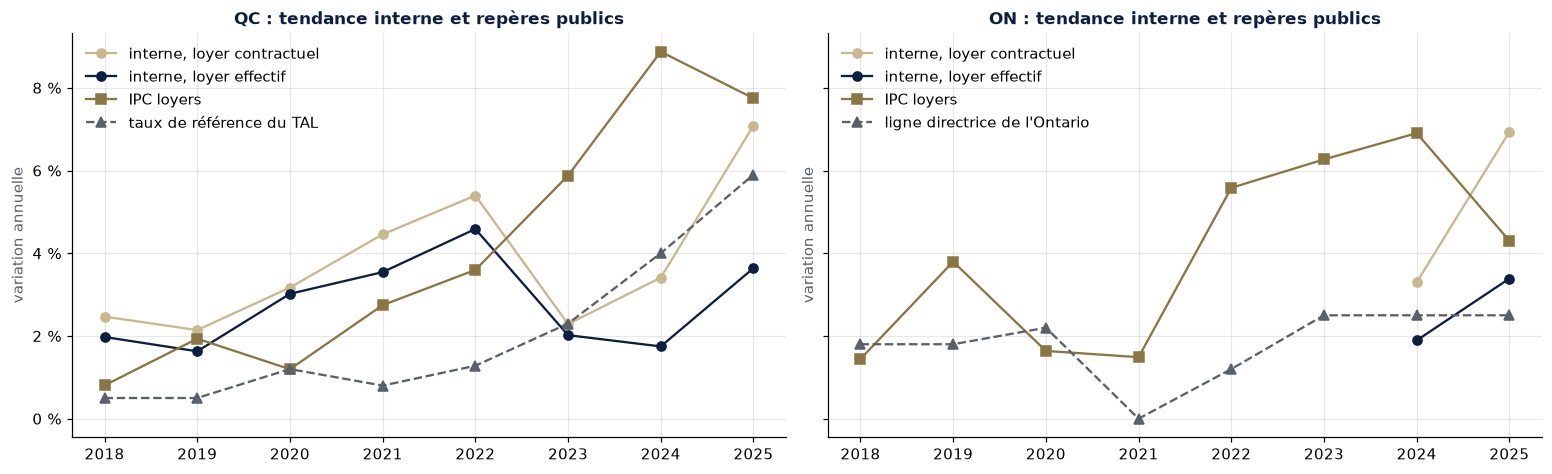

- Depuis 2021, l'écart moyen « IPC loyers − hausse effective interne » vaut +2,66 pp au Québec et +2,96 pp en Ontario (années avec des paires). L'IPC loyers couvre tout le parc locatif de la province, surtout des logements anciens, et ne décrit pas les concessions de ces immeubles récents : il donne la direction du marché, pas le niveau de la hausse interne.
- Le taux du TAL de l'année est connu en janvier et encadre les renouvellements des immeubles québécois de plus de 5 ans. La ligne directrice de l'Ontario ne s'applique pas à The Met.
- L'information externe qui compte vraiment : le taux du TAL pour les renouvellements soumis au TAL, l'IPC loyers de l'année précédente pour le reste du marché; la SCHL confirme le contexte (6.5).

In [34]:
internal_series = {
    "internal_contract_pct": (GOLD, "o-", "interne, loyer contractuel"),
    "internal_effective_pct": (NAVY, "o-", "interne, loyer effectif"),
}
rule_labels = {QUEBEC: "taux de référence du TAL", ONTARIO: "ligne directrice de l'Ontario"}
public_series = cpi_rent_long.merge(rules_long, on=["year", "province"], how="outer")
public_series = public_series[public_series["year"].isin(DISPLAY_YEARS)].sort_values("year")
figure, province_axes = plt.subplots(
    ncols=2, figsize=WIDE_FIGURE_SIZE, layout="constrained", sharey=True, sharex=True
)
for axis, province in zip(province_axes, [QUEBEC, ONTARIO], strict=True):
    internal_rows = reconciliation[reconciliation["province"].eq(province)]
    public_rows = public_series[public_series["province"].eq(province)]
    for column, (color, style, label) in internal_series.items():
        axis.plot(internal_rows["year"], internal_rows[column], style, color=color, label=label)
    axis.plot(public_rows["year"], public_rows["cpi_rent_pct"], "s-", color=BRONZE, label="IPC loyers")
    axis.plot(public_rows["year"], public_rows["rule_pct"], "^--", color=GREY, label=rule_labels[province])
    axis.set_xticks(DISPLAY_YEARS)
    axis.set(title=f"{province} : tendance interne et repères publics", ylabel="variation annuelle")
    percent_axis(axis)
    axis.legend()
plt.show()

recent = reconciliation[reconciliation["year"].ge(BACKTEST_FIRST_YEAR)].assign(
    cpi_minus_effective=lambda frame: frame["cpi_rent_pct"] - frame["internal_effective_pct"]
)
gap_by_province = recent.groupby("province")["cpi_minus_effective"].mean()
show_markdown(
    f"- Depuis {BACKTEST_FIRST_YEAR}, l'écart moyen « IPC loyers − hausse effective interne » vaut "
    f"{fr_pp(gap_by_province[QUEBEC])} au Québec et {fr_pp(gap_by_province[ONTARIO])} en Ontario (années "
    "avec "
    "des paires). L'IPC loyers couvre tout le parc locatif de la province, surtout des logements anciens, "
    "et ne "
    "décrit pas les concessions de ces immeubles récents : il donne la direction du marché, pas le niveau "
    "de la "
    f"hausse interne.\n"
    "- Le taux du TAL de l'année est connu en janvier et encadre les renouvellements des immeubles "
    "québécois de plus "
    f"de {NEW_BUILDING_MAX_AGE_YEARS} ans. La ligne directrice de l'Ontario ne s'applique pas à The Met.\n"
    "- L'information externe qui compte vraiment : le taux du TAL pour les renouvellements soumis au TAL, "
    "l'IPC "
    f"loyers de l'année précédente pour le reste du marché; la SCHL confirme le contexte (6.5)."
)

### 6.5 Contexte de marché pour les concessions et la part des relocations

La SCHL ne sert pas à prévoir; elle explique. Un taux d'inoccupation qui monte signale un marché plus détendu, où les propriétaires concèdent davantage pour louer. Le taux de roulement du marché est donné comme contexte; la part des relocations du portefeuille, qui détermine la composition de la prévision 2026, est mesurée sur les paires.

In [35]:
def cmhc_value(area, measure, year):
    rows = cmhc_long[cmhc_long["area"].eq(area) & cmhc_long["measure"].eq(measure)]
    return rows[f"value_{year}"].iloc[0]


market_areas = {QUEBEC: "RMR de Montréal", ONTARIO: "RMR d'Ottawa"}
relocation_share = (
    pairs[pairs["year"].eq(LAST_DATA_YEAR)]
    .assign(is_relocation=lambda frame: ~frame["is_renewal"])
    .groupby("province")["is_relocation"]
    .mean()
    * PERCENT
)
market_lines = [
    f"- **{area}** : inoccupation {fr_pct(cmhc_value(area, 'vacancy', CMHC_PREVIOUS_YEAR), 1)} en octobre "
    f"{CMHC_PREVIOUS_YEAR}, {fr_pct(cmhc_value(area, 'vacancy', CMHC_LATEST_YEAR), 1)} en octobre "
    f"{CMHC_LATEST_YEAR}; roulement {fr_pct(cmhc_value(area, 'turnover', CMHC_LATEST_YEAR), 1)}; hausse du "
    "loyer "
    f"moyen (échantillon fixe) {fr_pct(cmhc_value(area, 'rent_change', CMHC_LATEST_YEAR), 1)}."
    for area in market_areas.values()
]
vacancy_rises = all(
    cmhc_value(area, "vacancy", CMHC_LATEST_YEAR) > cmhc_value(area, "vacancy", CMHC_PREVIOUS_YEAR)
    for area in market_areas.values()
)
vacancy_reading = (
    "monte dans les deux marchés : c'est cohérent avec des concessions plus fréquentes, puis plus grosses "
    "(section 4.4)"
    if vacancy_rises
    else "ne monte pas dans les deux marchés : elle n'explique pas à elle seule la hausse des concessions"
)
show_markdown(
    "\n".join(market_lines) + f"\n- Part des relocations dans les paires {LAST_DATA_YEAR} du portefeuille : "
    f"{fr_pct(relocation_share[QUEBEC], 0)} au Québec, {fr_pct(relocation_share[ONTARIO], 0)} en Ontario. "
    "Elle est "
    "mesurée sur les paires de l'extrait et n'est pas comparable au taux de roulement de la SCHL, calculé "
    "sur "
    "l'ensemble du parc locatif : le notebook ne calcule aucun taux d'occupation ou de roulement à partir "
    "de "
    f"l'extrait. La prévision garde la part observée en {LAST_DATA_YEAR}; le roulement de la SCHL reste un "
    "contexte "
    f"de marché.\n"
    f"- Entre octobre {CMHC_PREVIOUS_YEAR} et octobre {CMHC_LATEST_YEAR}, l'inoccupation {vacancy_reading}."
)

- **RMR de Montréal** : inoccupation 2,1 % en octobre 2024, 2,9 % en octobre 2025; roulement 9,4 %; hausse du loyer moyen (échantillon fixe) 7,4 %.
- **RMR d'Ottawa** : inoccupation 2,6 % en octobre 2024, 3,0 % en octobre 2025; roulement 15,4 %; hausse du loyer moyen (échantillon fixe) 3,5 %.
- Part des relocations dans les paires 2025 du portefeuille : 38 % au Québec, 46 % en Ontario. Elle est mesurée sur les paires de l'extrait et n'est pas comparable au taux de roulement de la SCHL, calculé sur l'ensemble du parc locatif : le notebook ne calcule aucun taux d'occupation ou de roulement à partir de l'extrait. La prévision garde la part observée en 2025; le roulement de la SCHL reste un contexte de marché.
- Entre octobre 2024 et octobre 2025, l'inoccupation monte dans les deux marchés : c'est cohérent avec des concessions plus fréquentes, puis plus grosses (section 4.4).

### 6.6 Signaux : loyer affiché → loyer contractuel → loyer effectif

À quel signal se fier ? Pour chaque relocation, nous prenons le dernier loyer affiché de l'unité entre le mois de signature et les trois mois qui le précèdent, puis nous mesurons l'écart du loyer contractuel et du loyer effectif avec ce loyer affiché.

In [36]:
def month_index(dates):
    return dates.dt.year * MONTHS_PER_YEAR + dates.dt.month


relocation_leases = leases.loc[
    ~leases["is_renewal"], ["unit_id", "year", "sign_date", "contract_rent", "effective_rent"]
]
relocation_leases = relocation_leases.assign(
    sign_month=month_index(relocation_leases["sign_date"])
).sort_values("sign_month")
asking_months = asking[["unit_id", "asking_month", "asking_rent"]].assign(
    asking_month_index=month_index(asking["asking_month"])
)
signals = pd.merge_asof(
    relocation_leases,
    asking_months.sort_values("asking_month_index"),
    left_on="sign_month",
    right_on="asking_month_index",
    by="unit_id",
    direction="backward",
    tolerance=ASKING_LOOKBACK_MONTHS,
)
matched_signals = signals[signals["asking_rent"].notna()]
matched_signals = matched_signals.assign(
    asking_to_contract_pct=(matched_signals["contract_rent"] / matched_signals["asking_rent"] - 1) * PERCENT,
    asking_to_effective_pct=(matched_signals["effective_rent"] / matched_signals["asking_rent"] - 1)
    * PERCENT,
)
signals_by_year = (
    signals.assign(matched=signals["asking_rent"].notna())
    .groupby("year")
    .agg(relocations=("unit_id", "size"), matched_pct=("matched", "mean"))
    .join(
        matched_signals.groupby("year").agg(
            pairs=("unit_id", "size"),
            asking_to_contract_pct=("asking_to_contract_pct", "median"),
            asking_to_effective_pct=("asking_to_effective_pct", "median"),
        )
    )
)
signals_by_year = signals_by_year.assign(matched_pct=signals_by_year["matched_pct"] * PERCENT)
signals_by_year = mask_small_cells(
    signals_by_year.assign(pairs=signals_by_year["pairs"].fillna(0).astype(int)),
    "pairs",
    ["asking_to_contract_pct", "asking_to_effective_pct"],
).loc[DISPLAY_FIRST_YEAR:]
signal_overall = {
    "asking_to_contract_pct": matched_signals["asking_to_contract_pct"].median(),
    "asking_to_effective_pct": matched_signals["asking_to_effective_pct"].median(),
}
show_table(signals_by_year.drop(columns="pairs"), hide_index=False)

,relocations,relocations avec un loyer affiché (%),loyer contractuel vs affiché (%),loyer effectif vs affiché (%)
année,,,,
2018,121,"74,38","-2,49","-3,75"
2019,231,"74,89","-2,24","-3,40"
2020,172,"71,51","-2,18","-4,28"
2021,136,"72,06","-1,53","-4,29"
2022,190,"66,84","-1,94","-5,27"
2023,447,"77,40","-1,98","-6,39"
2024,474,"71,94","-1,63","-8,56"
2025,475,"74,11","-1,91","-11,86"


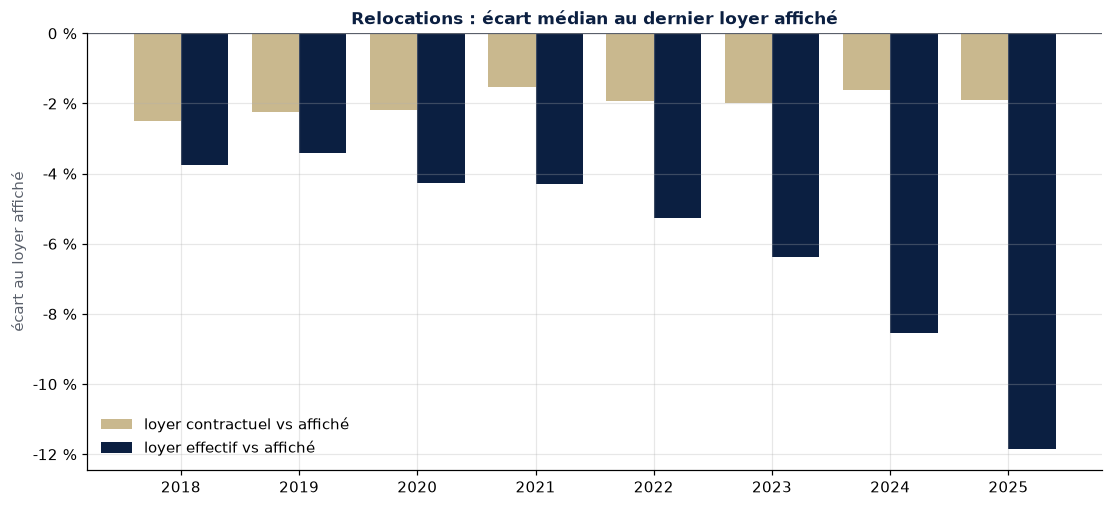

Sur 1719 relocations avec un loyer affiché, le loyer contractuel est en médiane **-1,91 %** par rapport au dernier loyer affiché, et le loyer effectif **-6,61 %**. Le loyer affiché est un plafond de négociation : il annonce la direction du marché, mais il surestime ce que JADCO perçoit. Le signal le plus fiable reste la hausse à unité constante des baux signés, en loyer effectif.

In [37]:
signal_years = signals_by_year.index.to_numpy()
figure, axis = plt.subplots(figsize=FIGURE_SIZE, layout="constrained")
axis.bar(
    signal_years - BAR_OFFSET,
    signals_by_year["asking_to_contract_pct"],
    width=BAR_WIDTH,
    color=GOLD,
    label="loyer contractuel vs affiché",
)
axis.bar(
    signal_years + BAR_OFFSET,
    signals_by_year["asking_to_effective_pct"],
    width=BAR_WIDTH,
    color=NAVY,
    label="loyer effectif vs affiché",
)
axis.axhline(0, color=GREY, linewidth=AXIS_LINE_WIDTH)
axis.set(title="Relocations : écart médian au dernier loyer affiché", ylabel="écart au loyer affiché")
percent_axis(axis)
axis.legend()
plt.show()
show_markdown(
    f"Sur {len(matched_signals)} relocations avec un loyer affiché, le loyer contractuel est en médiane "
    f"**{fr_pct(signal_overall['asking_to_contract_pct'])}** par rapport au dernier loyer affiché, et le "
    "loyer "
    f"effectif **{fr_pct(signal_overall['asking_to_effective_pct'])}**. Le loyer affiché est un plafond de "
    "négociation : il annonce la direction du marché, mais il surestime ce que JADCO perçoit. Le signal le "
    "plus "
    f"fiable reste la hausse à unité constante des baux signés, en loyer effectif."
)

## 7. Prévision 2026 et backtest

### 7.1 Ce qu'on sait au moment de prévoir

Pour une année cible Y, chaque méthode n'utilise que l'information publiée avant la fin de janvier Y. Le backtest respecte la même règle : pour prévoir 2023, rien de 2023 n'est utilisé, sauf ce qui est publié en janvier 2023.

| Source | Information utilisée pour prévoir Y |
|---|---|
| TAL | Taux de référence de Y, publié en janvier Y |
| Ontario | Ligne directrice de Y, publiée à l'été Y−1 |
| IPC (Statistique Canada) | Moyenne annuelle de Y−1, publiée en janvier Y |
| SCHL | Enquête d'octobre Y−1, contexte seulement |
| Baux internes | Paires dont le nouveau bail commence avant Y; âge des immeubles mesuré sur ces baux |

### 7.2 Méthode retenue, choisie d'avance

Pour chaque segment (renouvellement ou relocation × Québec ou Ontario) et chaque régime d'immeuble :

1. **Tendance interne** : hausse contractuelle médiane du segment l'année précédente.
2. **Ancre externe**, selon le segment et le régime de l'immeuble : renouvellement québécois dans un immeuble de plus de 5 ans → taux de référence du TAL de l'année cible; renouvellement ontarien soumis à la ligne directrice → ligne directrice de l'année cible; tous les autres baux (section F, The Met exemptée, toutes les relocations) → IPC loyers de la province, moyenne de l'année précédente.
3. **Hausse contractuelle prévue** = moyenne à poids égaux de la tendance interne et de l'ancre externe.
4. **Effet des concessions** : on retire l'écart observé l'année précédente entre hausse contractuelle et hausse effective du segment (on suppose qu'il persiste).
5. **Agrégation par bail** : chaque paire de l'année précédente garde sa hausse effective, déplacée de la révision de son segment et de son régime, c'est-à-dire de la moitié de l'écart entre son ancre et la hausse contractuelle de son segment. Au Québec, les renouvellements d'un même segment n'ont donc pas tous la même ancre (taux du TAL pour les immeubles de plus de 5 ans, IPC loyers en section F). La médiane de ces hausses donne le chiffre du portefeuille, de chaque province, de chaque immeuble et de chaque taille de logement. La composition (part des renouvellements, des provinces, des immeubles) est donc celle de l'année précédente, et le chiffre prévu est bien la médiane par bail, comme la définition de la section 1. Ce n'est pas une moyenne pondérée des médianes de segment, qui donnerait un autre chiffre (section 7.6).

**Pourquoi des poids égaux.** La littérature sur la combinaison de prévisions (Clemen, 1989) montre qu'une moyenne simple de prévisions de sources différentes fait en général aussi bien, ou mieux, qu'une combinaison aux poids estimés, surtout quand l'historique est court. Notre historique de paires est court (il commence en 2018) : estimer des poids reviendrait à surajuster le backtest. La tendance interne connaît le portefeuille (immeubles récents, concessions); l'ancre externe connaît les règles et le marché de l'année cible.

**Choisie avant le test.** La méthode et ses paramètres ont été fixés sur ces arguments, avant de calculer les erreurs du backtest 2021-2025. Ces années servent à tester, pas à choisir. Toutes les méthodes concurrentes sont publiées avec leurs erreurs :
- **Persistance** : la hausse effective de l'année précédente;
- **Tendance interne** : la moyenne des hausses effectives des trois années précédentes;
- **Ancre externe seule, moins l'effet des concessions** : la même mécanique avec un poids nul sur la tendance interne; l'effet des concessions observé l'année précédente reste retiré;
- **Régression par unité** : la régression du notebook de départ (spécification fixe, section 7.3), réentraînée chaque année sur les seules données antérieures.

Avec un poids de 1 sur la tendance interne, la méthode retenue redonne exactement la persistance; avec un poids de 0, l'ancre externe seule. Elle se situe entre les deux.

In [38]:
def build_external(tal_table, guideline_table, cpi_changes):
    cpi_rent = cpi_changes[cpi_changes["series"] == RENT_SERIES]
    return {
        "tal_pct": tal_table.set_index("year")["tal_pct"],
        "ontario_guideline_pct": guideline_table.set_index("year")["guideline_pct"],
        "cpi_rent_pct": cpi_rent.pivot(index="year", columns="province", values="change_pct"),
    }


def load_external():
    return build_external(
        pd.read_csv(TAL_FILE), pd.read_csv(ONTARIO_FILE), annual_cpi_changes(read_cpi_series())
    )


def external_anchor(rows, lease_history, target_year, external):
    regime = rows["prop_code"].map(building_regimes_for(lease_history, target_year))
    rule_anchor = regime.map(
        {
            REGIME_TAL: external["tal_pct"].loc[target_year],
            REGIME_ONTARIO_GUIDELINE: external["ontario_guideline_pct"].loc[target_year],
        }
    )
    rule_source = regime.map(
        {
            REGIME_TAL: f"taux du TAL {target_year}",
            REGIME_ONTARIO_GUIDELINE: f"ligne directrice de l'Ontario {target_year}",
        }
    )
    uses_rule = rows["is_renewal"] & rule_anchor.notna()
    cpi_anchor = rows["province"].map(external["cpi_rent_pct"].loc[target_year - 1])
    cpi_source = "IPC loyers " + rows["province"] + f" {target_year - 1}"
    return pd.DataFrame(
        {
            "anchor_pct": rule_anchor.where(uses_rule, cpi_anchor),
            "anchor_source": rule_source.where(uses_rule, cpi_source),
        },
        index=rows.index,
    )


def combine_forecast(pair_history, lease_history, target_year, external, internal_weight=INTERNAL_WEIGHT):
    base = pair_history[pair_history["year"] == target_year - 1]
    segment_contract = base.groupby(SEGMENT_COLUMNS)["contract_growth_pct"].transform("median")
    anchors = external_anchor(base, lease_history, target_year, external)
    revision = (1 - internal_weight) * (anchors["anchor_pct"] - segment_contract)
    return base.assign(
        anchor_pct=anchors["anchor_pct"],
        anchor_source=anchors["anchor_source"],
        revision_pp=revision,
        forecast_contract_pct=base["contract_growth_pct"] + revision,
        forecast_effective_pct=base["effective_growth_pct"] + revision,
    )


def combination_forecast(pair_history, lease_history, target_year, external):
    forecast = combine_forecast(pair_history, lease_history, target_year, external)
    return float(forecast["forecast_effective_pct"].median())


def external_anchor_forecast(pair_history, lease_history, target_year, external):
    forecast = combine_forecast(pair_history, lease_history, target_year, external, internal_weight=0)
    return float(forecast["forecast_effective_pct"].median())


def persistence_forecast(pair_history, lease_history, target_year, external):
    return float(pair_history.loc[pair_history["year"] == target_year - 1, "effective_growth_pct"].median())


def internal_trend_forecast(pair_history, lease_history, target_year, external):
    window = pair_history[pair_history["year"].between(target_year - TREND_WINDOW_YEARS, target_year - 1)]
    return float(window.groupby("year")["effective_growth_pct"].median().mean())


external = build_external(tal_rates, ontario_guideline, cpi_annual)

### 7.3 La régression concurrente

C'est la régression du notebook de départ, reprise avec une spécification fixe : régression linéaire sur variables standardisées, cible = logarithme du rapport des loyers effectifs, variables = renouvellement, Ontario, chambres, superficie, durée du bail précédent (en années), concession au bail précédent, hausse médiane de l'année précédente et indicateurs d'immeuble. Pour une année cible, elle est réentraînée sur les paires antérieures seulement, puis appliquée aux unités dont le dernier bail se termine au plus tard dans l'année cible, sous les deux hypothèses (renouvellement ou relocation) pondérées par la part historique des renouvellements. La médiane des prédictions donne sa prévision.

In [39]:
def regression_features(rows, lag_market_growth, building_codes):
    base = pd.DataFrame(
        {
            "is_renewal": rows["is_renewal"].astype(float),
            "is_ontario": rows["province"].eq(ONTARIO).astype(float),
            "bedrooms": rows["bedrooms"].astype(float),
            "sqft": rows["sqft"].astype(float),
            "prev_term_years": rows["prev_term_months"] / MONTHS_PER_YEAR,
            "prev_concession": rows["prev_has_concession"].astype(float),
            "lag_market_growth_pct": (rows["year"] - 1).map(lag_market_growth),
        },
        index=rows.index,
    )
    dummies = pd.DataFrame(
        {f"building_{code}": rows["prop_code"].eq(code).astype(float) for code in building_codes[1:]},
        index=rows.index,
    )
    return base.join(dummies)


def regression_forecast(pair_history, lease_history, target_year, external):
    lag_market_growth = pair_history.groupby("year")["effective_growth_pct"].median()
    building_codes = sorted(pair_history["prop_code"].unique())
    training = regression_features(pair_history, lag_market_growth, building_codes)
    complete = training.notna().all(axis=1)
    target = np.log1p(pair_history.loc[complete, "effective_growth_pct"] / PERCENT)
    model = make_pipeline(StandardScaler(), LinearRegression()).fit(training[complete], target)
    latest = lease_history.sort_values("lease_start").drop_duplicates(UNIT_KEY, keep="last")
    expiring = latest[latest["lease_end"].dt.year <= target_year]
    expiring = expiring.assign(
        year=target_year,
        prev_term_months=expiring["term_months"],
        prev_has_concession=expiring["has_concession"],
    )
    renewal_share = pair_history["is_renewal"].mean()
    renewal_growth, relocation_growth = (
        np.expm1(
            model.predict(
                regression_features(expiring.assign(is_renewal=flag), lag_market_growth, building_codes)
            )
        )
        * PERCENT
        for flag in (True, False)
    )
    return float(np.median(renewal_share * renewal_growth + (1 - renewal_share) * relocation_growth))

### 7.4 Les fonctions `backtest()` et `estimate_2026()`

`backtest(leases, target_year, external, method)` refait la prévision d'une année passée avec l'information disponible fin janvier de cette année (baux antérieurs, règles et IPC selon le tableau 7.1), puis la compare à la hausse effective observée (médiane par bail). Elle renvoie l'année, la prévision, l'observé et l'erreur (prévu − observé, en points de %).

`estimate_2026(leases, asking, external)` applique la méthode retenue à 2026 et renvoie la hausse centrale en %. `external` contient les taux du TAL, les lignes directrices de l'Ontario et l'IPC loyers; s'il est absent, il est relu dans `public_sources/`. `asking` est conservé dans la signature d'origine : les loyers affichés sont un signal descriptif (section 6.6) mais n'entrent pas dans la prévision, parce qu'ils surestiment chaque année le loyer contractuel (section 6.6).

In [40]:
forecast_methods = {
    "combination": {
        "label": "Combinaison interne/externe par segment et régime (retenue)",
        "function": combination_forecast,
    },
    "persistence": {"label": "Persistance de l'année précédente", "function": persistence_forecast},
    "internal_trend": {
        "label": f"Tendance interne, moyenne sur {TREND_WINDOW_YEARS} ans",
        "function": internal_trend_forecast,
    },
    "external_anchor": {
        "label": "Ancre externe seule (TAL, ligne directrice, IPC), moins l'effet des concessions",
        "function": external_anchor_forecast,
    },
    "unit_regression": {
        "label": "Régression par unité, réentraînée chaque année",
        "function": regression_forecast,
    },
}


def backtest(leases, target_year, external=None, method=CHOSEN_METHOD):
    external = load_external() if external is None else external
    all_same_unit_growth = same_unit_growth(leases)
    pair_history = all_same_unit_growth[all_same_unit_growth["year"] < target_year]
    lease_history = leases[leases["year"] < target_year]
    predicted = forecast_methods[method]["function"](pair_history, lease_history, target_year, external)
    actual = float(
        all_same_unit_growth.loc[all_same_unit_growth["year"] == target_year, "effective_growth_pct"].median()
    )
    return {"year": target_year, "predicted": predicted, "actual": actual, "error": predicted - actual}


def estimate_2026(leases, asking, external=None):
    external = load_external() if external is None else external
    return combination_forecast(same_unit_growth(leases), leases, FORECAST_YEAR, external)

### 7.5 Backtest 2021-2025

Chaque méthode prévoit chaque année de 2021 à 2025 avec l'information de fin janvier de l'année. Le test imposé porte sur 2023-2025 (colonne mise en évidence); 2021-2025 donne un test plus long.

In [41]:
backtest_results = pd.DataFrame(
    [
        {"method": method, **backtest(leases, year, external, method)}
        for method in forecast_methods
        for year in BACKTEST_YEARS
    ]
)
method_names = {method: spec["label"] for method, spec in forecast_methods.items()}
predicted_view = backtest_results.pivot(index="year", columns="method", values="predicted")[
    list(forecast_methods)
]
predicted_view = predicted_view.rename(columns=method_names).assign(
    actual=backtest_results.groupby("year")["actual"].first()
)
error_view = backtest_results.pivot(index="year", columns="method", values="error")[
    list(forecast_methods)
].rename(columns=method_names)
show_markdown("**Prévu et observé (hausse effective, %)**")
show_table(predicted_view, hide_index=False, highlight_columns=["actual"])
show_markdown("**Erreur : prévu − observé (pp)**")
show_table(error_view, hide_index=False)

**Prévu et observé (hausse effective, %)**

méthode,Combinaison interne/externe par segment et régime (retenue),Persistance de l'année précédente,"Tendance interne, moyenne sur 3 ans","Ancre externe seule (TAL, ligne directrice, IPC), moins l'effet des concessions","Régression par unité, réentraînée chaque année",observé (%)
année,,,,,,
2021,"2,08","3,02","2,21","1,14","-0,06","3,54"
2022,"2,75","3,54","2,73","1,87","5,93","4,59"
2023,"3,42","4,59","3,72","2,48","7,11","2,02"
2024,"3,59","2,02","3,38","5,17","4,50","1,77"
2025,"3,78","1,77","2,79","5,76","3,49","3,58"


**Erreur : prévu − observé (pp)**

méthode,Combinaison interne/externe par segment et régime (retenue),Persistance de l'année précédente,"Tendance interne, moyenne sur 3 ans","Ancre externe seule (TAL, ligne directrice, IPC), moins l'effet des concessions","Régression par unité, réentraînée chaque année"
année,,,,,
2021,"-1,46","-0,52","-1,34","-2,40","-3,60"
2022,"-1,84","-1,04","-1,86","-2,71","1,35"
2023,"1,40","2,57","1,70","0,46","5,09"
2024,"1,82","0,25","1,61","3,40","2,73"
2025,"0,21","-1,80","-0,78","2,19","-0,08"


libellé,erreur absolue moyenne 2023-2025 (pp),erreur absolue moyenne 2021-2025 (pp)
Combinaison interne/externe par segment et régime (retenue),"1,14","1,35"
Persistance de l'année précédente,"1,54","1,24"
"Tendance interne, moyenne sur 3 ans","1,36","1,46"
"Ancre externe seule (TAL, ligne directrice, IPC), moins l'effet des concessions","2,02","2,23"
"Régression par unité, réentraînée chaque année","2,63","2,57"


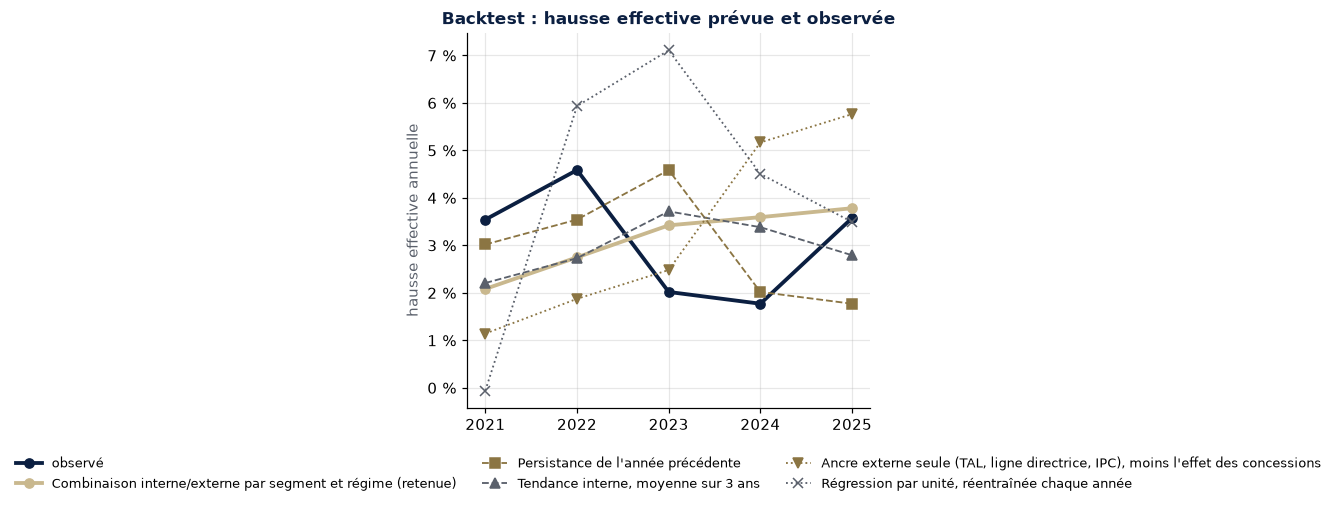

Sur le test imposé 2023-2025, la méthode retenue se trompe en moyenne de **1,14 pp** (rang 1 sur 5); sur 2021-2025, de **1,35 pp** (rang 2). La régression par unité se trompe de 2,63 pp sur 2023-2025. La méthode a été choisie avant ce test; le classement est publié tel quel.

In [42]:
absolute_errors = backtest_results.assign(absolute_error=backtest_results["error"].abs())
method_comparison = pd.DataFrame(
    {
        "label": pd.Series(method_names),
        "mae_2023_2025_pp": absolute_errors[absolute_errors["year"].isin(IMPOSED_TEST_YEARS)]
        .groupby("method")["absolute_error"]
        .mean(),
        "mae_2021_2025_pp": absolute_errors.groupby("method")["absolute_error"].mean(),
    }
).loc[list(forecast_methods)]
show_table(method_comparison, highlight_columns=["mae_2023_2025_pp"])

figure, axis = plt.subplots(figsize=FIGURE_SIZE, layout="constrained")
actual_by_year = backtest_results.groupby("year")["actual"].first()
method_styles = {
    "combination": (GOLD, "o-", BOLD_LINE_WIDTH),
    "persistence": (BRONZE, "s--", THIN_LINE_WIDTH),
    "internal_trend": (GREY, "^--", THIN_LINE_WIDTH),
    "external_anchor": (BRONZE, "v:", THIN_LINE_WIDTH),
    "unit_regression": (GREY, "x:", THIN_LINE_WIDTH),
}
axis.plot(actual_by_year.index, actual_by_year, "o-", color=NAVY, linewidth=BOLD_LINE_WIDTH, label="observé")
for method, spec in forecast_methods.items():
    rows = backtest_results[backtest_results["method"].eq(method)]
    color, style, width = method_styles[method]
    axis.plot(rows["year"], rows["predicted"], style, color=color, linewidth=width, label=spec["label"])
axis.set(title="Backtest : hausse effective prévue et observée", ylabel="hausse effective annuelle")
axis.set_xticks(BACKTEST_YEARS)
percent_axis(axis)
axis.legend(fontsize="small", **LEGEND_BELOW)
plt.show()

imposed_rank = method_comparison["mae_2023_2025_pp"].rank().loc[CHOSEN_METHOD]
full_rank = method_comparison["mae_2021_2025_pp"].rank().loc[CHOSEN_METHOD]
show_markdown(
    f"Sur le test imposé {IMPOSED_TEST_FIRST_YEAR}-{LAST_DATA_YEAR}, la méthode retenue se trompe en moyenne "
    "de "
    f"**{fr_points(method_comparison.loc[CHOSEN_METHOD, 'mae_2023_2025_pp'])}** "
    f"(rang {imposed_rank:.0f} sur {len(method_comparison)}); sur {BACKTEST_FIRST_YEAR}-{LAST_DATA_YEAR}, de "
    f"**{fr_points(method_comparison.loc[CHOSEN_METHOD, 'mae_2021_2025_pp'])}** "
    f"(rang {full_rank:.0f}). La régression par unité se trompe de "
    f"{fr_points(method_comparison.loc['unit_regression', 'mae_2023_2025_pp'])} sur "
    f"{IMPOSED_TEST_FIRST_YEAR}-"
    f"{LAST_DATA_YEAR}. La méthode a été choisie avant ce test; le classement est publié tel quel."
)

### 7.6 Prévision 2026

`estimate_2026()` donne la hausse centrale. Le détail vient de la même fonction de combinaison appliquée aux paires 2025 : par province, par segment, par immeuble et par nombre de chambres. Une case de moins de 5 paires est masquée. Saint-Elzéar 3 n'a aucune paire (location initiale) : il reçoit la prévision de sa province, avec une note.

In [43]:
central_pct = estimate_2026(leases, asking, external)
forecast_2026 = combine_forecast(pairs, leases, FORECAST_YEAR, external)
province_forecast = forecast_2026.groupby("province").agg(
    pairs=("lease_id", "size"),
    last_year_effective_pct=("effective_growth_pct", "median"),
    central_pct=("forecast_effective_pct", "median"),
    forecast_contract_pct=("forecast_contract_pct", "median"),
)
province_forecast = mask_small_cells(
    province_forecast, "pairs", ["last_year_effective_pct", "central_pct", "forecast_contract_pct"]
).loc[[QUEBEC, ONTARIO]]
segment_forecast = forecast_2026.groupby(SEGMENT_COLUMNS).agg(
    pairs=("lease_id", "size"),
    internal_contract_pct=("contract_growth_pct", "median"),
    internal_effective_pct=("effective_growth_pct", "median"),
    forecast_contract_pct=("forecast_contract_pct", "median"),
    central_pct=("forecast_effective_pct", "median"),
)
segment_forecast = segment_forecast.assign(
    concession_drag_pp=segment_forecast["internal_contract_pct"] - segment_forecast["internal_effective_pct"],
    weight=segment_forecast["pairs"] / segment_forecast["pairs"].sum(),
)
anchor_forecast = forecast_2026.groupby([*SEGMENT_COLUMNS, "anchor_source"]).agg(
    pairs=("lease_id", "size"),
    anchor_pct=("anchor_pct", "first"),
    revision_pp=("revision_pp", "first"),
    central_pct=("forecast_effective_pct", "median"),
)
anchor_forecast = mask_small_cells(anchor_forecast, "pairs", ["central_pct"])
segment_weighted = segment_forecast.assign(
    weighted_central=segment_forecast["central_pct"] * segment_forecast["pairs"]
)
province_weighted = segment_weighted.groupby("province")[["weighted_central", "pairs"]].sum()
province_weighted_pct = province_weighted["weighted_central"] / province_weighted["pairs"]
weighted_segment_pct = segment_weighted["weighted_central"].sum() / segment_weighted["pairs"].sum()
contract_2026_pct = forecast_2026["forecast_contract_pct"].median()
show_markdown(
    f"**Hausse effective centrale 2026 : {fr_pct(central_pct)}** (loyer contractuel : "
    f"{fr_pct(contract_2026_pct)})."
)
show_table(province_forecast, hide_index=False)
show_markdown("**Par segment**")
show_table(segment_forecast, hide_index=False)
show_markdown("**Par segment et ancre externe (régime de l'immeuble)**")
show_table(anchor_forecast, hide_index=False)
show_markdown(
    f"**Médiane par bail, pas moyenne des segments.** Le chiffre-titre ({fr_pct(central_pct)}) est la "
    "médiane de "
    "toutes les paires prévues, comme la définition de la section 1. La moyenne des médianes de segment, "
    "pondérée "
    f"par le nombre de paires, vaudrait {fr_pct(weighted_segment_pct)} "
    f"({fr_pct(province_weighted_pct[QUEBEC])} au "
    f"Québec, {fr_pct(province_weighted_pct[ONTARIO])} en Ontario). Les deux diffèrent parce que les hausses "
    "des "
    "renouvellements et des relocations se chevauchent : la médiane de l'ensemble n'est pas la moyenne des "
    "médianes."
)

**Hausse effective centrale 2026 : 3,07 %** (loyer contractuel : 6,59 %).

,paires,hausse effective 2025 (%),"prévision 2026, loyer effectif (%)","prévision 2026, loyer contractuel (%)"
province,,,,
QC,663,"3,64","3,39","6,73"
ON,117,"3,39","1,99","5,61"


**Par segment**

**Par segment et ancre externe (régime de l'immeuble)**

**Médiane par bail, pas moyenne des segments.** Le chiffre-titre (3,07 %) est la médiane de toutes les paires prévues, comme la définition de la section 1. La moyenne des médianes de segment, pondérée par le nombre de paires, vaudrait 3,46 % (3,67 % au Québec, 2,24 % en Ontario). Les deux diffèrent parce que les hausses des renouvellements et des relocations se chevauchent : la médiane de l'ensemble n'est pas la moyenne des médianes.

In [44]:
building_forecast = building_regimes[["name", "province", "regime"]].join(
    forecast_2026.groupby("prop_code").agg(
        pairs_2025=("lease_id", "size"), forecast_pct=("forecast_effective_pct", "median")
    )
)
building_forecast = building_forecast.assign(pairs_2025=building_forecast["pairs_2025"].fillna(0).astype(int))
has_enough_pairs = building_forecast["pairs_2025"] >= MIN_CELL_SIZE
has_no_pairs = building_forecast["pairs_2025"] == 0
building_forecast = building_forecast.assign(
    forecast_pct=building_forecast["forecast_pct"].where(
        has_enough_pairs,
        building_forecast["province"].map(province_forecast["central_pct"]).where(has_no_pairs),
    ),
    note=np.select(
        [has_no_pairs, ~has_enough_pairs, building_forecast.index == TRUNCATED_BUILDING_CODE],
        [LEASE_UP_NOTE, MASK_LABEL, building_forecast["regime"] + f"; extrait tronqué en {LAST_DATA_YEAR}"],
        default=building_forecast["regime"],
    ),
)
bedroom_forecast = forecast_2026.groupby("bedrooms").agg(
    pairs_2025=("lease_id", "size"), forecast_pct=("forecast_effective_pct", "median")
)
bedroom_forecast = mask_small_cells(bedroom_forecast, "pairs_2025", ["forecast_pct"]).rename(
    index=BEDROOM_LABELS
)
show_table(building_forecast.drop(columns="regime"))
show_table(bedroom_forecast, hide_index=False)

nom,province,paires 2025,prévision 2026 (%),note
Saint-Elzéar 1,QC,36,"2,15",TAL : taux de référence (immeuble de plus de 5 ans); extrait tronqué en 2025
Lévesque,QC,76,"1,75",TAL : taux de référence (immeuble de plus de 5 ans)
Daniel-Johnson 1,QC,56,"2,53",TAL : taux de référence (immeuble de plus de 5 ans)
Saint-Elzéar 2,QC,114,"2,58",TAL : taux de référence (immeuble de plus de 5 ans)
Daniel-Johnson 2,QC,71,"3,95","Section F : immeuble de 5 ans ou moins, loyer non fixé par le TAL"
Le Carlyle,QC,183,"3,83","Section F : immeuble de 5 ans ou moins, loyer non fixé par le TAL"
Westpark,QC,127,"4,17","Section F : immeuble de 5 ans ou moins, loyer non fixé par le TAL"
Saint-Elzéar 3,QC,0,"3,39","Location initiale : aucune paire, prévision de sa province"
The Met,ON,117,"1,99",Ontario : exemptée de la ligne directrice (premier bail après le 2018-11-15)


,paires 2025,prévision 2026 (%)
chambres,,
Studio,48,"1,96"
1 chambre,267,"3,19"
2 chambres,450,"3,19"
3 chambres,15,"1,52"


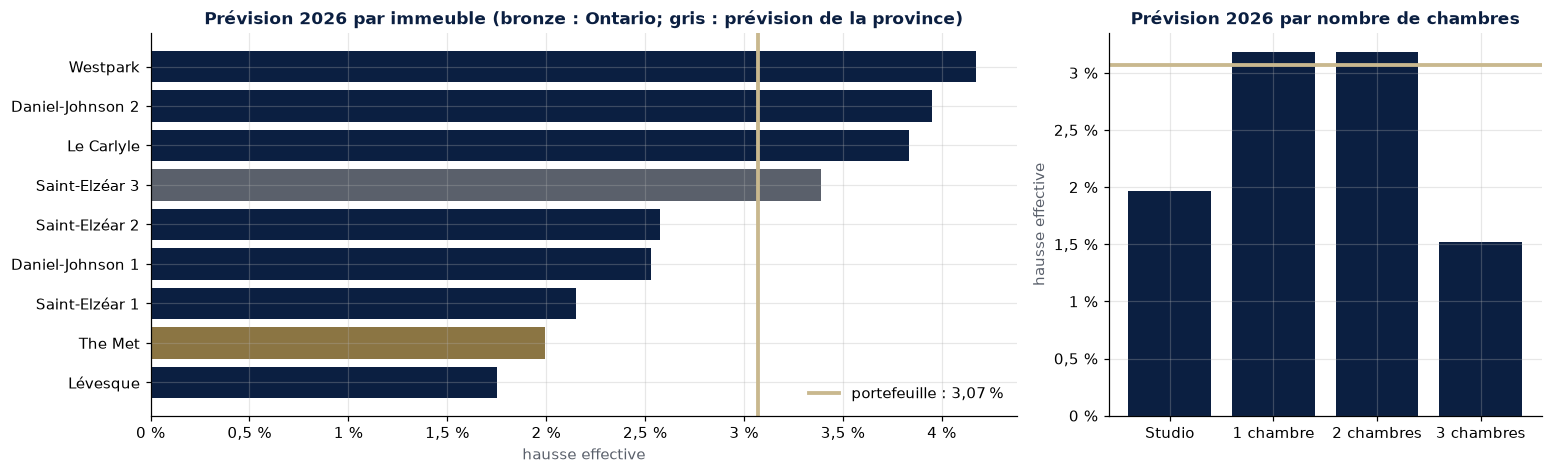

In [45]:
figure, (building_axis, bedroom_axis) = plt.subplots(
    ncols=2, figsize=WIDE_FIGURE_SIZE, layout="constrained", width_ratios=PANEL_WIDTH_RATIOS
)
building_plot = building_forecast.sort_values("forecast_pct")
building_colors = np.select(
    [building_plot["pairs_2025"].eq(0), building_plot["province"].eq(ONTARIO)], [GREY, BRONZE], default=NAVY
)
building_axis.barh(building_plot["name"], building_plot["forecast_pct"], color=building_colors)
building_axis.axvline(
    central_pct, color=GOLD, linewidth=BOLD_LINE_WIDTH, label=f"portefeuille : {fr_pct(central_pct)}"
)
building_axis.set(
    title=f"Prévision {FORECAST_YEAR} par immeuble (bronze : Ontario; gris : prévision de la province)",
    xlabel="hausse effective",
)
percent_axis(building_axis, axis_name="x")
building_axis.legend()
bedroom_axis.bar(bedroom_forecast.index, bedroom_forecast["forecast_pct"], color=NAVY)
bedroom_axis.axhline(central_pct, color=GOLD, linewidth=BOLD_LINE_WIDTH)
bedroom_axis.set(title=f"Prévision {FORECAST_YEAR} par nombre de chambres", ylabel="hausse effective")
percent_axis(bedroom_axis)
plt.show()

### 7.7 Contrôles et scénarios

- **Sensibilité à l'extrait tronqué** : la prévision est refaite sans les paires 2025 de Saint-Elzéar 1.
- **Version pondérée en dollars** : chaque paire pèse selon son loyer effectif 2025 (hausse des revenus).
- **Prévision 2026 de chaque méthode** : l'écart entre méthodes mesure l'incertitude de modèle.
- **Scénarios** : bas = plus basse des prévisions des méthodes simples (persistance, tendance interne, ancre externe) et de la méthode retenue, moins l'erreur absolue moyenne de la méthode retenue sur 2021-2025; haut = plus haute de ces prévisions, plus cette erreur. La période 2021-2025 est choisie d'avance parce qu'elle compte plus d'années que le test imposé.

In [46]:
without_truncated = pairs[
    ~(pairs["prop_code"].eq(TRUNCATED_BUILDING_CODE) & pairs["year"].eq(LAST_DATA_YEAR))
]
forecast_without_truncated_pct = combination_forecast(without_truncated, leases, FORECAST_YEAR, external)
truncation_sensitivity = pd.DataFrame(
    [
        {
            "variant": f"Avec {BUILDING_NAMES[TRUNCATED_BUILDING_CODE]} en {LAST_DATA_YEAR}",
            "observed_last_year_pct": pairs.loc[
                pairs["year"].eq(LAST_DATA_YEAR), "effective_growth_pct"
            ].median(),
            "forecast_pct": central_pct,
        },
        {
            "variant": f"Sans {BUILDING_NAMES[TRUNCATED_BUILDING_CODE]} en {LAST_DATA_YEAR}",
            "observed_last_year_pct": without_truncated.loc[
                without_truncated["year"].eq(LAST_DATA_YEAR), "effective_growth_pct"
            ].median(),
            "forecast_pct": forecast_without_truncated_pct,
        },
    ]
)
dollar_weighted_2026_pct = dollar_weighted_growth_pct(
    forecast_2026, "forecast_effective_pct", "effective_rent"
)
method_forecasts_2026 = pd.Series(
    {
        method: spec["function"](pairs, leases, FORECAST_YEAR, external)
        for method, spec in forecast_methods.items()
    }
)
scenario_error_pp = method_comparison.loc[CHOSEN_METHOD, "mae_2021_2025_pp"]
envelope = method_forecasts_2026[[*SIMPLE_METHODS, CHOSEN_METHOD]]
low_pct = envelope.min() - scenario_error_pp
high_pct = envelope.max() + scenario_error_pp
show_table(truncation_sensitivity)
show_table(
    pd.DataFrame({"label": pd.Series(method_names), "forecast_2026_pct": method_forecasts_2026}).loc[
        list(forecast_methods)
    ]
)
scenarios = pd.DataFrame(
    [
        {"scenario": "Bas", "value_pct": low_pct},
        {"scenario": "Central (méthode retenue)", "value_pct": central_pct},
        {"scenario": "Haut", "value_pct": high_pct},
        {"scenario": "Contrôle : loyer contractuel", "value_pct": contract_2026_pct},
        {"scenario": "Contrôle : pondéré en dollars", "value_pct": dollar_weighted_2026_pct},
    ]
)
show_table(scenarios)

variante,hausse effective observée 2025 (%),prévision 2026 (%)
Avec Saint-Elzéar 1 en 2025,"3,58","3,07"
Sans Saint-Elzéar 1 en 2025,"3,57","3,16"


libellé,prévision 2026 (%)
Combinaison interne/externe par segment et régime (retenue),"3,07"
Persistance de l'année précédente,"3,58"
"Tendance interne, moyenne sur 3 ans","2,46"
"Ancre externe seule (TAL, ligne directrice, IPC), moins l'effet des concessions","2,44"
"Régression par unité, réentraînée chaque année","4,15"


scénario,valeur (%)
Bas,"1,09"
Central (méthode retenue),"3,07"
Haut,"4,92"
Contrôle : loyer contractuel,"6,59"
Contrôle : pondéré en dollars,"3,28"


### 7.8 Sauvegarde du modèle et des résultats

`rent_model.json` garde, en clair, la méthode retenue et ses paramètres : poids, ancres 2026, poids des segments, effet des concessions par segment, date de coupure de l'information et date des données. `output/results.json` regroupe les résultats agrégés du notebook (aucune ligne CRM, cases de moins de 5 paires à `null`); il alimente la page de présentation.

In [47]:
segment_records = to_records(
    segment_forecast.reset_index(),
    [
        "province",
        "segment",
        "pairs",
        "internal_contract_pct",
        "internal_effective_pct",
        "concession_drag_pp",
        "forecast_contract_pct",
        "central_pct",
    ],
)
for record, weight in zip(segment_records, segment_forecast["weight"], strict=True):
    record["weight"] = round(float(weight), WEIGHT_DECIMALS)
anchor_records = to_records(
    anchor_forecast.reset_index(),
    ["province", "segment", "anchor_source", "pairs", "anchor_pct", "revision_pp", "central_pct"],
)
rent_model = {
    "method": CHOSEN_METHOD,
    "label": method_names[CHOSEN_METHOD],
    "definition": HEADLINE_DEFINITION,
    "forecast_year": FORECAST_YEAR,
    "data_as_of": DATA_AS_OF.date().isoformat(),
    "information_cutoff": INFORMATION_CUTOFF,
    "parameters": {
        "internal_weight": INTERNAL_WEIGHT,
        "external_weight": 1 - INTERNAL_WEIGHT,
        "min_gap_years": MIN_GAP_YEARS,
        "max_gap_years": MAX_GAP_YEARS,
        "new_building_max_age_years": NEW_BUILDING_MAX_AGE_YEARS,
        "ontario_exemption_date": ONTARIO_EXEMPTION_DATE.date().isoformat(),
        "concession_drag": "écart contractuel − effectif du segment l'année précédente, supposé persistant",
        "aggregation": (
            "médiane par bail des paires de l'année précédente déplacées de la révision de leur segment"
        ),
    },
    "anchors": {
        "tal_pct": clean_value(external["tal_pct"].loc[FORECAST_YEAR]),
        "tal_method": tal_rates.set_index("year").loc[FORECAST_YEAR, "tal_method"],
        "ontario_guideline_pct": clean_value(external["ontario_guideline_pct"].loc[FORECAST_YEAR]),
        "cpi_rent_previous_year_pct": {
            province: clean_value(value)
            for province, value in external["cpi_rent_pct"].loc[LAST_DATA_YEAR].items()
        },
        "building_regimes": building_regimes_for(leases, FORECAST_YEAR).to_dict(),
    },
    "segments": segment_records,
    "segment_anchors": anchor_records,
    "forecast": {
        "central_pct": clean_value(central_pct),
        "low_pct": clean_value(low_pct),
        "high_pct": clean_value(high_pct),
    },
    "backtest_mae_pp": {
        "2023_2025": clean_value(method_comparison.loc[CHOSEN_METHOD, "mae_2023_2025_pp"]),
        "2021_2025": clean_value(method_comparison.loc[CHOSEN_METHOD, "mae_2021_2025_pp"]),
    },
}
MODEL_FILE.write_text(json.dumps(rent_model, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")
show_markdown(f"Modèle écrit : `{MODEL_FILE}` ({len(segment_records)} segments).")

Modèle écrit : `rent_model.json` (4 segments).

In [48]:
last_year_pairs = pairs[pairs["year"].eq(LAST_DATA_YEAR)]
renewal_share_last_year = last_year_pairs["is_renewal"].mean() * PERCENT
last_year_drag_pp = (
    last_year_pairs["contract_growth_pct"].median() - last_year_pairs["effective_growth_pct"].median()
)
assumptions = [
    f"Composition 2026 = composition des paires {LAST_DATA_YEAR} : {fr_pct(renewal_share_last_year, 0)} de "
    f"renouvellements, mêmes provinces et mêmes immeubles.",
    f"L'écart {LAST_DATA_YEAR} entre hausse contractuelle et hausse effective persiste en {FORECAST_YEAR} "
    f"({fr_pp(last_year_drag_pp)} pour le portefeuille) : les concessions continuent de croître au même "
    "rythme.",
    f"Ancres connues fin janvier {FORECAST_YEAR} : taux du TAL "
    f"{fr_pct(external['tal_pct'].loc[FORECAST_YEAR], 1)} "
    f"({tal_rates.set_index('year').loc[FORECAST_YEAR, 'tal_method']}) pour les renouvellements québécois "
    "des "
    f"immeubles de plus de {NEW_BUILDING_MAX_AGE_YEARS} ans; IPC loyers {LAST_DATA_YEAR} "
    f"({fr_pct(external['cpi_rent_pct'].loc[LAST_DATA_YEAR, QUEBEC])} au Québec, "
    f"{fr_pct(external['cpi_rent_pct'].loc[LAST_DATA_YEAR, ONTARIO])} en Ontario) pour les autres baux.",
    f"The Met est exemptée de la ligne directrice de l'Ontario (premier bail en "
    f"{building_regimes.loc[THE_MET_CODE, 'first_lease_year']}, après le {ONTARIO_EXEMPTION_DATE.date()}).",
    f"L'âge d'un immeuble est mesuré depuis son premier bail dans l'extrait (section F si "
    f"{NEW_BUILDING_MAX_AGE_YEARS} ans ou moins).",
    f"{BUILDING_NAMES[LEASE_UP_BUILDING_CODE]} (location initiale) reçoit la prévision du Québec; "
    f"{BUILDING_NAMES[TRUNCATED_BUILDING_CODE]} est gardé malgré l'extrait tronqué en {LAST_DATA_YEAR} "
    f"(le retirer fait passer la prévision de {fr_pct(central_pct)} à "
    f"{fr_pct(forecast_without_truncated_pct)}).",
    f"Les données s'arrêtent le {DATA_AS_OF.date()}; aucun mois de l'IPC postérieur n'est utilisé.",
]
sources = [
    {
        "name": "Statistique Canada, tableau 18-10-0004-01, Indice des prix à la consommation",
        "url": STATCAN_URL,
    },
    {
        "name": "SCHL, Enquête sur les logements locatifs 2025, RMR de Montréal (tableaux de données)",
        "url": CMHC_URL,
    },
    {
        "name": "SCHL, Enquête sur les logements locatifs 2025, RMR d'Ottawa (tableaux de données)",
        "url": CMHC_URL,
    },
    *[
        {
            "name": f"Tribunal administratif du logement, taux {row.year} ({row.tal_method})",
            "url": row.source_url,
        }
        for row in tal_rates.itertuples()
    ],
    {
        "name": "Gouvernement de l'Ontario, ligne directrice sur l'augmentation des loyers",
        "url": ontario_guideline["source_url"].iloc[0],
    },
    {
        "name": "Clemen, R. T. (1989). Combining forecasts: A review and annotated bibliography. "
        "International Journal of Forecasting, 5(4), 559-583.",
        "url": CLEMEN_URL,
    },
]

In [49]:
mix_years_list = [int(year) for year in mix_table.index]
results = {
    "meta": {
        "as_of": DATA_AS_OF.date().isoformat(),
        "forecast_year": FORECAST_YEAR,
        "information_cutoff": INFORMATION_CUTOFF,
        "min_cell_size": MIN_CELL_SIZE,
        "imposed_test_years": IMPOSED_TEST_YEARS,
        "backtest_years": BACKTEST_YEARS,
    },
    "headline": {
        "definition": HEADLINE_DEFINITION,
        "note": HEADLINE_NOTE,
        "central_pct": clean_value(central_pct),
        "low_pct": clean_value(low_pct),
        "high_pct": clean_value(high_pct),
        "dollar_weighted_pct": clean_value(dollar_weighted_2026_pct),
        "contract_pct": clean_value(contract_2026_pct),
        "by_province": to_records(
            province_forecast.reset_index().rename(columns={"forecast_contract_pct": "contract_pct"}),
            ["province", "central_pct", "contract_pct"],
        ),
        "by_segment": [
            {**record, "weight": round(float(weight), WEIGHT_DECIMALS)}
            for record, weight in zip(
                to_records(segment_forecast.reset_index(), ["province", "segment", "central_pct"]),
                segment_forecast["weight"],
                strict=True,
            )
        ],
    },
    "data": {
        "tables": to_records(table_overview, ["name", "rows", "columns", "description"]),
        "renamed_columns": to_records(rename_spec, ["table", "source", "renamed", "meaning"]),
        "findings": to_records(findings, ["column", "documented_as", "actually", "evidence"]),
        "key_check": key_check,
    },
    "mix": {
        "years": mix_years_list,
        "naive_median_change_pct": clean_list(mix_table["naive_change_pct"]),
        "same_unit_effective_pct": clean_list(same_unit_by_year["effective_pct"].reindex(mix_years_list)),
        "median_sqft": clean_list(mix_table["median_sqft"]),
        "share_2bed_plus_pct": clean_list(mix_table["share_large_pct"]),
        "rent_per_sqft_change_pct": clean_list(mix_table["rent_per_sqft_change_pct"]),
        "leases_by_building_year": to_records(
            leases_by_building_year.rename_axis(index="building", columns=None)
            .reset_index()
            .melt(id_vars="building", var_name="year", value_name="leases"),
            ["building", "year", "leases"],
        ),
    },
    "same_unit": {
        "years": [int(year) for year in same_unit_by_year.index],
        "pairs": clean_list(same_unit_by_year["pairs"]),
        "contract_pct": clean_list(same_unit_by_year["contract_pct"]),
        "effective_pct": clean_list(same_unit_by_year["effective_pct"]),
        "filters": {
            "min_gap_years": MIN_GAP_YEARS,
            "max_gap_years": MAX_GAP_YEARS,
            "pairs_before_filter": len(all_pairs),
            "pairs_after_filter": len(pairs),
        },
    },
    "concessions": {
        "years": [int(year) for year in concession_by_year.index],
        "share_with_concession_pct": clean_list(concession_by_year["share_with_concession_pct"]),
        "average_discount_pct": clean_list(concession_by_year["average_discount_pct"]),
        "decomposition": to_records(
            decomposition.rename_axis("year").reset_index(), ["year", "total_pp", "frequency_pp", "size_pp"]
        ),
        "by_code": to_records(
            concession_codes,
            ["code", "label", "rows", "median_months", "median_share_of_rent_pct", "treatment"],
        ),
        "effective_formula_match_pct": clean_value(effective_formula_match_pct),
        "promopay_placeholder_by_year": to_records(placeholder_by_year, ["year", "rows"]),
    },
    "segments": {
        "rows": to_records(
            segment_by_year.assign(
                pairs=segment_by_year["pairs"]
                .where(segment_by_year["pairs"] >= MIN_CELL_SIZE)
                .astype("Int64")
            ),
            ["year", "province", "segment", "pairs", "contract_pct", "effective_pct"],
        ),
        "buildings": to_records(
            building_regimes.reset_index().rename(columns={"prop_code": "code"}),
            ["code", "name", "city", "province", "first_lease_year", "regime"],
        ),
    },
    "market": {
        "rules": to_records(
            rules.rename(columns={"guideline_pct": "ontario_guideline_pct"}),
            ["year", "tal_pct", "tal_method", "ontario_guideline_pct"],
        ),
        "cpi_rent": to_records(
            cpi_rent_long.pivot(index="year", columns="province", values="cpi_rent_pct")
            .loc[DISPLAY_FIRST_YEAR - 1 :]
            .rename(columns={QUEBEC: "qc_pct", ONTARIO: "on_pct"})
            .reset_index(),
            ["year", "qc_pct", "on_pct"],
        ),
        "cmhc": [
            {
                "area": area,
                "change_2024_pct": clean_value(cmhc_value(area, "rent_change", CMHC_PREVIOUS_YEAR)),
                "change_2025_pct": clean_value(cmhc_value(area, "rent_change", CMHC_LATEST_YEAR)),
                "vacancy_2024_pct": clean_value(cmhc_value(area, "vacancy", CMHC_PREVIOUS_YEAR)),
                "vacancy_2025_pct": clean_value(cmhc_value(area, "vacancy", CMHC_LATEST_YEAR)),
            }
            for area in CMHC_AREAS["area"]
        ],
        "reconciliation": to_records(
            reconciliation,
            [
                "year",
                "province",
                "internal_contract_pct",
                "internal_effective_pct",
                "cpi_rent_pct",
                "rule_pct",
            ],
        ),
    },
    "signals": {
        "asking_to_contract_pct": clean_value(signal_overall["asking_to_contract_pct"]),
        "asking_to_effective_pct": clean_value(signal_overall["asking_to_effective_pct"]),
        "by_year": to_records(
            signals_by_year.rename_axis("year").reset_index(),
            ["year", "asking_to_contract_pct", "asking_to_effective_pct"],
        ),
    },
    "forecast": {
        "method": method_names[CHOSEN_METHOD],
        "method_comparison": to_records(
            method_comparison.rename_axis("method").reset_index(),
            ["method", "label", "mae_2023_2025_pp", "mae_2021_2025_pp"],
        ),
        "backtest": to_records(
            backtest_results[backtest_results["method"].eq(CHOSEN_METHOD)].rename(
                columns={"predicted": "predicted_pct", "actual": "actual_pct", "error": "error_pp"}
            ),
            ["year", "predicted_pct", "actual_pct", "error_pp"],
        ),
        "by_building": to_records(
            building_forecast.rename(columns={"name": "building"}).assign(
                pairs_2025=building_forecast["pairs_2025"]
                .where(has_enough_pairs | has_no_pairs)
                .astype("Int64")
            ),
            ["building", "province", "pairs_2025", "forecast_pct", "note"],
        ),
        "by_bedrooms": to_records(
            bedroom_forecast.rename_axis("bedrooms").reset_index(), ["bedrooms", "pairs_2025", "forecast_pct"]
        ),
        "assumptions": assumptions,
    },
    "sources": sources,
}
OUTPUT_DIR.mkdir(exist_ok=True)
RESULTS_FILE.write_text(json.dumps(results, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")
show_markdown(f"Résultats écrits : `{RESULTS_FILE}` ({len(results)} sections).")

Résultats écrits : `output\results.json` (11 sections).

## 8. Bilan

Le bilan est produit à partir des valeurs calculées ci-dessus.

In [50]:
imposed_backtest = backtest_results[
    backtest_results["method"].eq(CHOSEN_METHOD) & backtest_results["year"].isin(IMPOSED_TEST_YEARS)
]
province_lines = [
    f"- **{province}** : {fr_pct(row['central_pct'])} en loyer effectif "
    f"({fr_pct(row['forecast_contract_pct'])} en "
    f"loyer contractuel), sur {int(row['pairs'])} paires {LAST_DATA_YEAR}."
    for province, row in province_forecast.iterrows()
]
backtest_lines = [
    f"| {row.year} | {fr_pct(row.predicted)} | {fr_pct(row.actual)} | {fr_pp(row.error)} |"
    for row in imposed_backtest.itertuples()
]
method_spread_pp = envelope.max() - envelope.min()
imposed_error_pp = method_comparison.loc[CHOSEN_METHOD, "mae_2023_2025_pp"]
same_rounded = fr_points(method_spread_pp) == fr_points(imposed_error_pp)
coincidence_note = (
    " Les deux premiers chiffres sont égaux par coïncidence; ils mesurent des choses différentes."
    if same_rounded
    else ""
)
contract_above_high = contract_2026_pct > high_pct
contract_position = (
    "au-dessus du scénario haut : les scénarios ne couvrent pas ce cas"
    if contract_above_high
    else "dans l'intervalle des scénarios"
)
limit_lines = [
    f"- Historique court : le backtest porte sur {len(BACKTEST_YEARS)} années. Trois chiffres d'incertitude "
    "à ne pas "
    f"confondre : l'écart entre les prévisions {FORECAST_YEAR} des méthodes simples et retenue "
    f"({fr_points(method_spread_pp)}); l'erreur absolue moyenne {IMPOSED_TEST_FIRST_YEAR}-{LAST_DATA_YEAR} "
    "de la "
    f"méthode retenue ({fr_points(imposed_error_pp)}); son erreur {BACKTEST_FIRST_YEAR}-{LAST_DATA_YEAR} "
    f"({fr_points(scenario_error_pp)}), ajoutée de part et d'autre de l'écart entre méthodes pour former les "
    f"scénarios.{coincidence_note}",
    "- L'effet des concessions est l'hypothèse la plus incertaine. Les scénarios supposent qu'il persiste. "
    "S'il "
    f"cessait de croître, la hausse effective se rapprocherait de la hausse contractuelle prévue "
    f"({fr_pct(contract_2026_pct)}; scénario haut : {fr_pct(high_pct)}), {contract_position}.",
    f"- Le taux du TAL {FORECAST_YEAR} suit une nouvelle méthode de calcul : la série des taux est rompue.",
    "- La SCHL ne couvre que deux enquêtes : elle sert de contexte, sans backtest.",
    "- Selon le notebook de départ fourni par JADCO, l'extrait contient une part fixe des unités de chaque "
    "immeuble, et les consignes excluent tout calcul d'occupation : l'analyse mesure des variations de "
    "loyer, "
    "jamais l'occupation.",
]
bilan_lines = [
    f"### Hausse de loyer {FORECAST_YEAR} : **{fr_pct(central_pct)}**",
    f"Scénarios : bas **{fr_pct(low_pct)}**, central **{fr_pct(central_pct)}**, haut **{fr_pct(high_pct)}**.",
    "",
    f"**Définition.** {HEADLINE_DEFINITION}",
    "",
    "**Par province.**",
    *province_lines,
    "",
    f"**Contrôles.** Loyer contractuel : {fr_pct(contract_2026_pct)}. Version pondérée en dollars (hausse "
    "des "
    f"revenus) : {fr_pct(dollar_weighted_2026_pct)}.",
    "",
    "**Méthode.** Par segment (renouvellement ou relocation × province) et régime d'immeuble, moyenne à "
    "poids égaux de la hausse "
    "contractuelle de l'année précédente et d'une ancre publique (taux du TAL de l'année pour les "
    "renouvellements "
    "soumis au TAL, IPC loyers de l'année précédente pour les autres baux), moins l'effet des concessions "
    "observé "
    "l'année précédente; agrégation par bail. Méthode choisie avant le backtest.",
    "",
    f"**Backtest.** Erreur absolue moyenne {IMPOSED_TEST_FIRST_YEAR}-{LAST_DATA_YEAR} (test imposé) : "
    f"{fr_points(method_comparison.loc[CHOSEN_METHOD, 'mae_2023_2025_pp'])}; {BACKTEST_FIRST_YEAR}-"
    f"{LAST_DATA_YEAR} : {fr_points(method_comparison.loc[CHOSEN_METHOD, 'mae_2021_2025_pp'])}. Régression "
    "par "
    "unité du notebook de départ : "
    f"{fr_points(method_comparison.loc['unit_regression', 'mae_2023_2025_pp'])} "
    f"sur {IMPOSED_TEST_FIRST_YEAR}-{LAST_DATA_YEAR}.",
    "",
    "| Année | Prévu | Observé | Erreur |",
    "|---|---|---|---|",
    *backtest_lines,
    "",
    "**Hypothèses.**",
    *[f"- {assumption}" for assumption in assumptions],
    "",
    "**Limites.**",
    *limit_lines,
]
show_markdown("\n".join(bilan_lines))

### Hausse de loyer 2026 : **3,07 %**
Scénarios : bas **1,09 %**, central **3,07 %**, haut **4,92 %**.

**Définition.** Hausse annualisée du loyer effectif (sRentEffective) à unité constante : chaque unité (sPropCode + sUnitCode) comparée à son bail précédent; médiane sur toutes les paires comparables (premiers baux et paires hors filtre d'écart exclus), renouvellements et relocations selon leur part observée.

**Par province.**
- **QC** : 3,39 % en loyer effectif (6,73 % en loyer contractuel), sur 663 paires 2025.
- **ON** : 1,99 % en loyer effectif (5,61 % en loyer contractuel), sur 117 paires 2025.

**Contrôles.** Loyer contractuel : 6,59 %. Version pondérée en dollars (hausse des revenus) : 3,28 %.

**Méthode.** Par segment (renouvellement ou relocation × province) et régime d'immeuble, moyenne à poids égaux de la hausse contractuelle de l'année précédente et d'une ancre publique (taux du TAL de l'année pour les renouvellements soumis au TAL, IPC loyers de l'année précédente pour les autres baux), moins l'effet des concessions observé l'année précédente; agrégation par bail. Méthode choisie avant le backtest.

**Backtest.** Erreur absolue moyenne 2023-2025 (test imposé) : 1,14 pp; 2021-2025 : 1,35 pp. Régression par unité du notebook de départ : 2,63 pp sur 2023-2025.

| Année | Prévu | Observé | Erreur |
|---|---|---|---|
| 2023 | 3,42 % | 2,02 % | +1,40 pp |
| 2024 | 3,59 % | 1,77 % | +1,82 pp |
| 2025 | 3,78 % | 3,58 % | +0,21 pp |

**Hypothèses.**
- Composition 2026 = composition des paires 2025 : 61 % de renouvellements, mêmes provinces et mêmes immeubles.
- L'écart 2025 entre hausse contractuelle et hausse effective persiste en 2026 (+3,47 pp pour le portefeuille) : les concessions continuent de croître au même rythme.
- Ancres connues fin janvier 2026 : taux du TAL 3,1 % (nouvelle méthode — pourcentage de base) pour les renouvellements québécois des immeubles de plus de 5 ans; IPC loyers 2025 (7,75 % au Québec, 4,30 % en Ontario) pour les autres baux.
- The Met est exemptée de la ligne directrice de l'Ontario (premier bail en 2023, après le 2018-11-15).
- L'âge d'un immeuble est mesuré depuis son premier bail dans l'extrait (section F si 5 ans ou moins).
- Saint-Elzéar 3 (location initiale) reçoit la prévision du Québec; Saint-Elzéar 1 est gardé malgré l'extrait tronqué en 2025 (le retirer fait passer la prévision de 3,07 % à 3,16 %).
- Les données s'arrêtent le 2025-12-31; aucun mois de l'IPC postérieur n'est utilisé.

**Limites.**
- Historique court : le backtest porte sur 5 années. Trois chiffres d'incertitude à ne pas confondre : l'écart entre les prévisions 2026 des méthodes simples et retenue (1,14 pp); l'erreur absolue moyenne 2023-2025 de la méthode retenue (1,14 pp); son erreur 2021-2025 (1,35 pp), ajoutée de part et d'autre de l'écart entre méthodes pour former les scénarios. Les deux premiers chiffres sont égaux par coïncidence; ils mesurent des choses différentes.
- L'effet des concessions est l'hypothèse la plus incertaine. Les scénarios supposent qu'il persiste. S'il cessait de croître, la hausse effective se rapprocherait de la hausse contractuelle prévue (6,59 %; scénario haut : 4,92 %), au-dessus du scénario haut : les scénarios ne couvrent pas ce cas.
- Le taux du TAL 2026 suit une nouvelle méthode de calcul : la série des taux est rompue.
- La SCHL ne couvre que deux enquêtes : elle sert de contexte, sans backtest.
- Selon le notebook de départ fourni par JADCO, l'extrait contient une part fixe des unités de chaque immeuble, et les consignes excluent tout calcul d'occupation : l'analyse mesure des variations de loyer, jamais l'occupation.

## 9. Références

**Données publiques**
- Statistique Canada. Tableau 18-10-0004-01, Indice des prix à la consommation mensuel, non désaisonnalisé (loyers et ensemble, Québec et Ontario). https://www150.statcan.gc.ca/t1/tbl1/fr/tv.action?pid=1810000401
- Société canadienne d'hypothèques et de logement (SCHL). Enquête sur les logements locatifs, octobre 2025, tableaux de données des RMR de Montréal et d'Ottawa (tableaux 1.1.1, 1.1.5 et 1.1.6). https://www.cmhc-schl.gc.ca/professionals/housing-markets-data-and-research/housing-data/data-tables/rental-market/rental-market-report-data-tables
- Tribunal administratif du logement, calcul de l'augmentation des loyers :
  - 2017 : https://www.tal.gouv.qc.ca/fr/actualites/detail?code=fixation-de-loyer-2017-exemple-supplementaire-de-calcul
  - 2018 : https://www.tal.gouv.qc.ca/fr/actualites/detail?code=le-calcul-de-l-augmentation-des-loyers-en-2018
  - 2019 : https://www.tal.gouv.qc.ca/fr/actualites/detail?code=le-calcul-de-l-augmentation-des-loyers-en-2019
  - 2020 : https://www.tal.gouv.qc.ca/fr/actualites/detail?code=le-calcul-de-l-augmentation-des-loyers-en-2020
  - 2021 : https://www.tal.gouv.qc.ca/fr/actualites/detail?code=le-calcul-de-l-augmentation-des-loyers-en-2021
  - 2022 : https://www.tal.gouv.qc.ca/sites/default/files/COMMUNIQUE_FIXATION_2022_FR.pdf
  - 2023 : https://www.tal.gouv.qc.ca/sites/default/files/COMMUNIQUE_FIXATION_2023_FR.pdf
  - 2024 : https://www.tal.gouv.qc.ca/sites/default/files/COMMUNIQUE_FIXATION_2024_FR.pdf
  - 2025 : https://www.tal.gouv.qc.ca/sites/default/files/COMMUNIQUE_FIXATION_2025_FR.pdf
  - 2026 : https://www.tal.gouv.qc.ca/fr/reconduction-du-bail-et-fixation-de-loyer/pourcentages-applicables-aux-criteres-de-fixation-de-loyer
- Gouvernement de l'Ontario. Ligne directrice sur l'augmentation des loyers (2017 à 2026). https://www.ontario.ca/page/residential-rent-increases

**Travaux préexistants**
- JADCO, mandat « Clés en main » (CodeML 2026) : données CRM de la Collection Équinoxe (`equinoxe_listings.csv`, `equinoxe_lease_history.csv`, `equinoxe_concessions.csv`, `equinoxe_asking_history.csv`) et notebook de départ `starter.ipynb`. Repris et adaptés de ce notebook : la structure de chargement, la convention `h` / `s` de Yardi, le tableau des codes de concession, la démonstration de l'effet de composition, la méthode à unité constante `same_unit_growth`, la régression par unité (concurrente de la section 7.3) et les signatures des fonctions `estimate_2026()` et `backtest()`.

**Article**
- Clemen, R. T. (1989). Combining forecasts: A review and annotated bibliography. *International Journal of Forecasting*, 5(4), 559-583. https://doi.org/10.1016/0169-2070(89)90012-5

**Bibliothèques Python** (versions dans `requirements.txt`)
- pandas, NumPy, Matplotlib, scikit-learn, openpyxl, Jupyter (avec nbconvert et ipykernel).

**Outils**
- Outils d'IA utilisés : Claude (Anthropic) et OpenAI Codex, comme aide à l'écriture et à la vérification du code.